STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 8 SFR bins for rMZR

Σ_SFR bins:
  Number of bins: 8

8 SFR bins:
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 3: -3.0–-2.5
  Bin 4: -2.5–-2.0
  Bin 5: -2.0–-1.5
  B

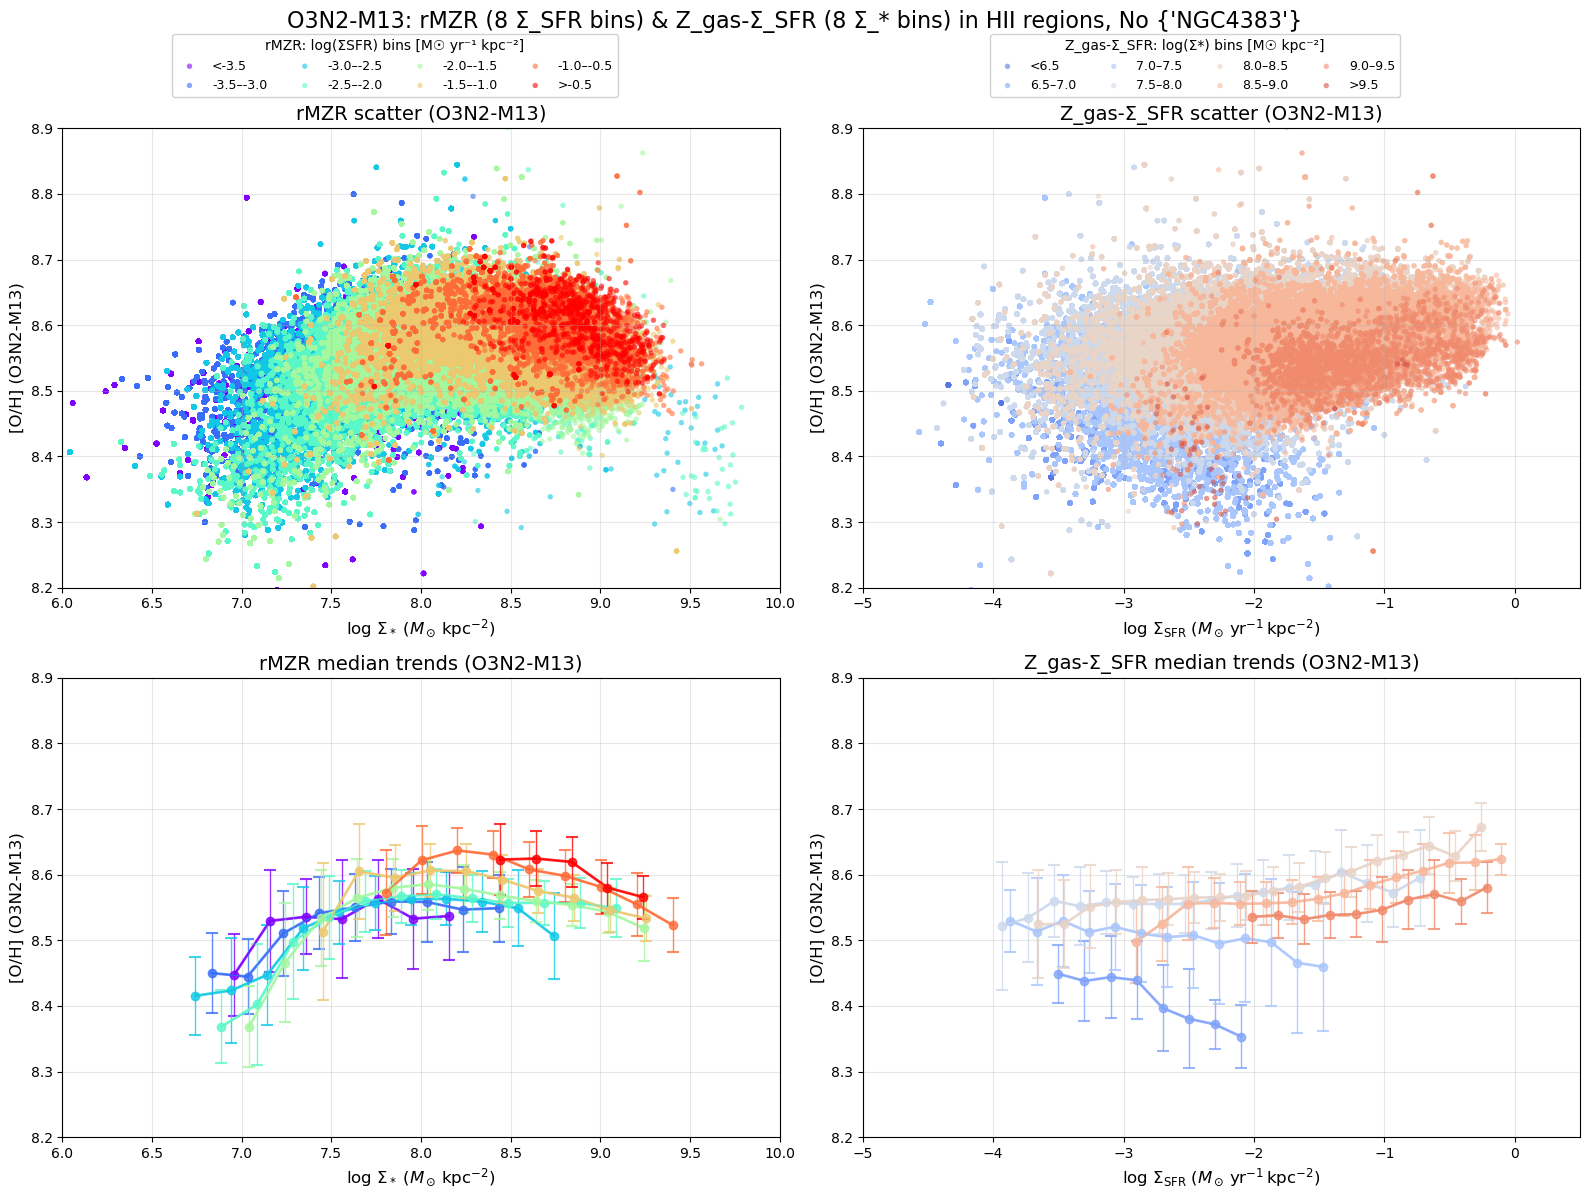


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [1]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 8 Σ_SFR bins for rMZR analysis
# Bins: <-3.5, [-3.5,-3.0), [-3.0,-2.5), [-2.5,-2.0), [-2.0,-1.5), [-1.5,-1.0), [-1.0,-0.5), >=-0.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)

# Define 8 bins with specific boundaries
n_bins = 8
# Bin edges: -inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, +inf
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]

print(f"\nΣ_SFR bins:")
print(f"  Number of bins: {n_bins}")

# Create bin labels
bin_labels = [
    '<-3.5',
    '-3.5–-3.0',
    '-3.0–-2.5',
    '-2.5–-2.0',
    '-2.0–-1.5',
    '-1.5–-1.0',
    '-1.0–-0.5',
    '>-0.5'
]

print(f"\n8 SFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 8 Σ_* bins for Z_gas-Σ_SFR analysis
# Bins: <6.5, [6.5,7.0), [7.0,7.5), [7.5,8.0), [8.0,8.5), [8.5,9.0), [9.0,9.5), >=9.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)

# Define 8 Σ_* bins with specific boundaries
n_bins_sigmaM = 8
# Bin edges: -inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, +inf
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]

print(f"\nΣ_* bins:")
print(f"  Number of bins: {n_bins_sigmaM}")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = [
    '<6.5',
    '6.5–7.0',
    '7.0–7.5',
    '7.5–8.0',
    '8.0–8.5',
    '8.5–9.0',
    '9.0–9.5',
    '>9.5'
]

print(f"\n8 Σ_* bins:")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 8 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Use O3N2-M13 data
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes (swap top-right with bottom-left)
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 8 Σ_SFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# Format rMZR scatter plot
ax_rMZR_scatter.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.set_title(f'rMZR scatter ({calib_name_HII})', fontsize=14)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.set_title(f'rMZR median trends ({calib_name_HII})', fontsize=14)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (in 8 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (now bin by Σ_SFR)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(sfr_centers_HII) > 0:
            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1

# Format Z_gas-Σ_SFR scatter plot
ax_Zgas_scatter.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_scatter.set_title(f'Z_gas-Σ_SFR scatter ({calib_name_HII})', fontsize=14)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends
# =============================================================================
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_median.set_title(f'Z_gas-Σ_SFR median trends ({calib_name_HII})', fontsize=14)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# Add overall title
fig.suptitle(f'{calib_name_HII}: rMZR (8 Σ_SFR bins) & Z_gas-Σ_SFR (8 Σ_* bins) in HII regions, No {excluded_galaxies}', 
             fontsize=16, y=0.995)

# Add legends - one for each row (positions unchanged)
legend1 = fig.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                    bbox_to_anchor=(0.25, 0.98), ncol=4, fontsize=9, framealpha=0.9,
                    title='rMZR: log(ΣSFR) bins [M☉ yr⁻¹ kpc⁻²]', title_fontsize=10)
legend2 = fig.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                    bbox_to_anchor=(0.75, 0.98), ncol=4, fontsize=9, framealpha=0.9,
                    title='Z_gas-Σ_SFR: log(Σ*) bins [M☉ kpc⁻²]', title_fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig('Plot_20251117_MAUVE_Monthly_Meetiing/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_20251117_MAUVE_Monthly_Meetiing/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")


Offset relations and Pearson r vs Σ_* (excluding: {'NGC4383'})
All galaxies (for color assignment): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Galaxies used in this analysis: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698

Processing IC3392 ...
  Σ* range: 7.310 to 9.297
  Global Δlog(Σ_SFR) axis limits: ±1.953
  Global Δ[O/H] axis limits: ±0.259
  Pearson r in each Σ_* bin (95% contour + trend, per galaxy):
    Bin 01 (7.39): n=209, r=N/A (no trend or too few in 95%)
    Bin 02 (7.56): n=139, r=N/A (no trend or too few in 95%)
    Bin 03 (7.72): n=244, r=N/A (no trend or too few in 95%)
    Bin 04 (7.89): n=975, r=N/A (no trend or too few in 95%)
    Bin 05 (8.06): n=2954, r=0.274
    Bin 06 (8.22): n=4888, r=0.262
    Bin 07 (8.39): n=2989, r=0.168
    Bin 08 (8.55): n=1266, r=0.256
    Bin 09 (8.72): n=750, r=0.149
    Bin 10 (8.88): n=

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_46534/2411549964.py:447: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


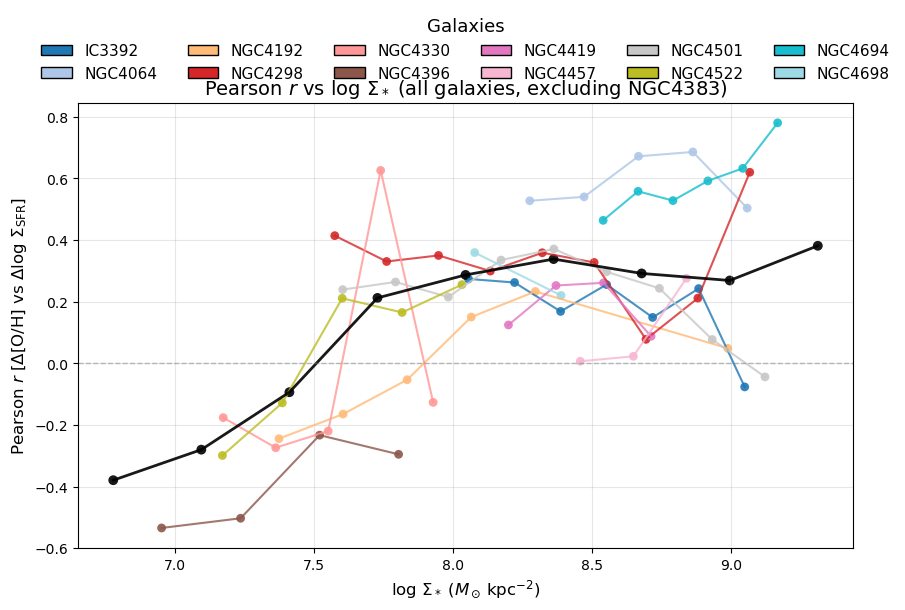

In [2]:
# ------------------------------------------------------------------
# Offset relations: Δ[O/H] vs Δlog Σ_SFR in Σ_* bins
# For all galaxies (excluding NGC4383) and Pearson r vs Σ_* summary
# Pearson r uses only points inside 95% contour and only if trend exists
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Galaxy list and color map (reserve color for excluded galaxy)
# ------------------------------------------------------------------
all_bin_centers = []  # Σ_* bin centers for which r is valid (per-galaxy)
all_r_values = []     # Pearson r (per-galaxy)
all_galaxy_indices = []

# Also store all spaxels across galaxies to compute a global trend
global_sigM_list = []
global_sigSFR_list = []
global_oh_list = []
global_gal_index_list = []

# Build full galaxy list from available FITS files (including excluded)
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}

# Build galaxy -> color mapping over ALL galaxies (so excluded keeps its color)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Now define the working sample that EXCLUDES NGC4383 for analysis/plotting
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print(f"Offset relations and Pearson r vs Σ_* (excluding: {excluded_galaxies})")
print("All galaxies (for color assignment):", ", ".join(galaxies_all))
print("Galaxies used in this analysis:", ", ".join(galaxies))
print("=" * 80)

# ------------------------------------------------------------------
# Loop over galaxies and compute Pearson r per Σ_* bin (per-galaxy)
# and collect global spaxels for combined trend
# ------------------------------------------------------------------
for gal_index, gal in enumerate(galaxies):
    print(f"\nProcessing {gal} ...")
    try:
        sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f"  Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        print("  No valid pixels.")
        continue

    # Collect into global arrays for combined analysis
    global_sigM_list.append(sigM[valid_all].ravel())
    global_sigSFR_list.append(sigSFR[valid_all].ravel())
    global_oh_list.append(oh_o3n2_map[valid_all].ravel())
    global_gal_index_list.append(np.full(np.sum(valid_all), gal_index, dtype=int))

    # 1. Define 12 Σ_* bins for this galaxy
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])

    # 2. Global symmetric limits for this galaxy (for reference / consistency)
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            if np.any(np.isfinite(sfr_offset)):
                global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            if np.any(np.isfinite(oh_offset)):
                global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    print(f"  Σ* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")

    # 3. Compute Pearson r in each Σ_* bin using 95% contour logic (per galaxy)
    print("  Pearson r in each Σ_* bin (95% contour + trend, per galaxy):")
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        n_pixels = np.sum(bin_mask)

        if n_pixels <= 0:
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, r=N/A")
            continue

        # Values in this Σ_* bin
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_o3n2_map[bin_mask]

        # Offsets within this bin
        sfr_bin_mean = np.mean(sfr_bin)
        oh_bin_mean = np.mean(oh_bin)

        sfr_offset = sfr_bin - sfr_bin_mean
        oh_offset = oh_bin - oh_bin_mean

        valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

        if np.sum(valid_corr) <= 2:
            pearson_r = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 95% contour and mask, as in the 12-panel code
        # ------------------------------------------------------------------
        contour_mask = np.zeros_like(valid_corr, dtype=bool)
        if np.sum(valid_corr) > 20:
            try:
                H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                   bins=30, density=True)
                H_flat = H.flatten()
                H_sorted = np.sort(H_flat)[::-1]
                H_cumsum = np.cumsum(H_sorted)
                H_cumsum /= H_cumsum[-1]
                threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                x_centers = (xedges[:-1] + xedges[1:]) / 2
                y_centers = (yedges[:-1] + yedges[1:]) / 2

                x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                x_idx = np.clip(x_idx, 0, H.shape[0] - 1)
                y_idx = np.clip(y_idx, 0, H.shape[1] - 1)

                inside = H[x_idx, y_idx] >= threshold_95
                contour_mask[valid_corr] = inside
            except Exception:
                contour_mask[:] = True
        else:
            contour_mask[:] = True

        # ------------------------------------------------------------------
        # Median trend using only points inside 95% contour
        # ------------------------------------------------------------------
        x_trend = sfr_offset[contour_mask]
        y_trend = oh_offset[contour_mask]

        centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                bin_width=0.2,
                                                                min_unique=20)

        # Require at least 2 median-trend points for a valid trend
        has_trend = centers.size >= 2

        # ------------------------------------------------------------------
        # Pearson r: only for points inside 95% contour and only if trend exists
        # ------------------------------------------------------------------
        if has_trend and np.sum(contour_mask & valid_corr) > 2:
            try:
                pearson_r, pearson_p = pearsonr(sfr_offset[contour_mask & valid_corr],
                                                oh_offset[contour_mask & valid_corr])
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r={pearson_r:.3f}")
            except Exception:
                pearson_r = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (error)")
        else:
            pearson_r = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (no trend or too few in 95%)")

        # Store only valid r values
        if np.isfinite(pearson_r):
            all_bin_centers.append(sigmaM_bin_centers[i])
            all_r_values.append(pearson_r)
            all_galaxy_indices.append(gal_index)

# ------------------------------------------------------------------
# Prepare global arrays for combined Pearson vs Σ_* (all galaxies)
# ------------------------------------------------------------------
if global_sigM_list:
    global_sigM = np.concatenate(global_sigM_list)
    global_sigSFR = np.concatenate(global_sigSFR_list)
    global_oh = np.concatenate(global_oh_list)
else:
    global_sigM = np.array([])
    global_sigSFR = np.array([])
    global_oh = np.array([])

# ------------------------------------------------------------------
# Convert collected per-galaxy Pearson r data to arrays
# ------------------------------------------------------------------
all_bin_centers = np.array(all_bin_centers)
all_r_values = np.array(all_r_values)
all_galaxy_indices = np.array(all_galaxy_indices)

print("\n" + "=" * 80)
print("Summary: number of Σ_* bins with valid Pearson r (per galaxy):", len(all_r_values))
print("=" * 80)

# ------------------------------------------------------------------
# Compute combined Pearson r vs Σ_* over all galaxies (same method)
# ------------------------------------------------------------------
global_bin_centers = []
global_r_values = []

if global_sigM.size > 0:
    # Define 12 Σ_* bins for the combined sample
    n_bins_global = 12
    sigmaM_min_g = np.nanmin(global_sigM)
    sigmaM_max_g = np.nanmax(global_sigM)
    sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
    sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

    print("\nComputing combined Pearson r in Σ_* bins (all galaxies together)...")
    for i in range(n_bins_global):
        if i == 0:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])
        elif i == n_bins_global - 1:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i+1])
        else:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])

        n_pix_g = np.sum(bin_mask_g)
        if n_pix_g <= 0:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, r=N/A")
            continue

        sfr_bin_g = global_sigSFR[bin_mask_g]
        oh_bin_g = global_oh[bin_mask_g]

        sfr_mean_g = np.mean(sfr_bin_g)
        oh_mean_g = np.mean(oh_bin_g)

        sfr_off_g = sfr_bin_g - sfr_mean_g
        oh_off_g = oh_bin_g - oh_mean_g

        valid_corr_g = np.isfinite(sfr_off_g) & np.isfinite(oh_off_g)
        if np.sum(valid_corr_g) <= 2:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (insufficient valid points)")
            continue

        contour_mask_g = np.zeros_like(valid_corr_g, dtype=bool)
        if np.sum(valid_corr_g) > 20:
            try:
                Hg, xedges_g, yedges_g = np.histogram2d(sfr_off_g[valid_corr_g], oh_off_g[valid_corr_g],
                                                       bins=30, density=True)
                H_flat_g = Hg.flatten()
                H_sorted_g = np.sort(H_flat_g)[::-1]
                H_cumsum_g = np.cumsum(H_sorted_g)
                H_cumsum_g /= H_cumsum_g[-1]
                thr95_g = H_sorted_g[np.where(H_cumsum_g >= 0.95)[0][0]]

                xcent_g = (xedges_g[:-1] + xedges_g[1:]) / 2
                ycent_g = (yedges_g[:-1] + yedges_g[1:]) / 2

                x_idx_g = np.searchsorted(xedges_g, sfr_off_g[valid_corr_g], side='right') - 1
                y_idx_g = np.searchsorted(yedges_g, oh_off_g[valid_corr_g], side='right') - 1

                x_idx_g = np.clip(x_idx_g, 0, Hg.shape[0] - 1)
                y_idx_g = np.clip(y_idx_g, 0, Hg.shape[1] - 1)

                inside_g = Hg[x_idx_g, y_idx_g] >= thr95_g
                contour_mask_g[valid_corr_g] = inside_g
            except Exception:
                contour_mask_g[:] = True
        else:
            contour_mask_g[:] = True

        x_trend_g = sfr_off_g[contour_mask_g]
        y_trend_g = oh_off_g[contour_mask_g]

        centers_g, medians_g, stds_g, counts_g = calculate_binned_stats(x_trend_g, y_trend_g,
                                                                        bin_width=0.2,
                                                                        min_unique=20)

        has_trend_g = centers_g.size >= 3

        if has_trend_g and np.sum(contour_mask_g & valid_corr_g) > 2:
            try:
                r_g, p_g = pearsonr(sfr_off_g[contour_mask_g & valid_corr_g],
                                     oh_off_g[contour_mask_g & valid_corr_g])
                global_bin_centers.append(sigmaM_centers_g[i])
                global_r_values.append(r_g)
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r={r_g:.3f}")
            except Exception:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (error)")
        else:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (no trend or too few in 95%)")

global_bin_centers = np.array(global_bin_centers)
global_r_values = np.array(global_r_values)

# ------------------------------------------------------------------
# Plot Pearson r vs Σ_* for all galaxies, with galaxy color legend
# and an additional combined (all galaxies) trend in black
# ------------------------------------------------------------------
if len(all_r_values) > 0:
    
    galaxy_indices_unique = np.unique(all_galaxy_indices)
    
    # Create figure with main axis and a thin top axis for legend
    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
    legend_ax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    legend_ax.axis('off')
    
    # Plot Pearson r vs Σ_* for each galaxy
    for idx in galaxy_indices_unique:
        mask = all_galaxy_indices == idx
        gal_name = galaxies[idx]
        color = galaxy_color_dict[gal_name]
        
        # Sort by Σ_* so lines are not scrambled
        x_vals = all_bin_centers[mask]
        y_vals = all_r_values[mask]
        order = np.argsort(x_vals)
        x_sorted = x_vals[order]
        y_sorted = y_vals[order]
        
        ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
        ax.scatter(x_sorted, y_sorted, color=color, s=40, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Add combined trend (all galaxies together) in black (no legend entry)
    if global_r_values.size > 0:
        order_g = np.argsort(global_bin_centers)
        ax.plot(global_bin_centers[order_g], global_r_values[order_g],
                color='black', linewidth=2.0, alpha=0.9, linestyle='-')
        ax.scatter(global_bin_centers[order_g], global_r_values[order_g],
                   color='black', s=50, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Axis formatting
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Pearson $r$ [Δ[O/H] vs Δ$\log\,\Sigma_{\mathrm{SFR}}$]', fontsize=12)
    ax.set_title(r'Pearson $r$ vs $\log\,\Sigma_*$ (all galaxies, excluding NGC4383)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # ------------------------------------------------------------------
    # Galaxy legend at the top using dummy patches (excluding NGC4383)
    # ------------------------------------------------------------------
    galaxy_names = [galaxies[idx] for idx in galaxy_indices_unique]
    legend_elements = [
        Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
        for gal in galaxy_names
]
    legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(galaxy_names), 6),
                      frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)
    
    plt.tight_layout()
    plt.show()
else:
    print("No valid Pearson r values to plot.")

Cell 3: 12-panel offset relations for all galaxies (excluding NGC4383)
All galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Used galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698


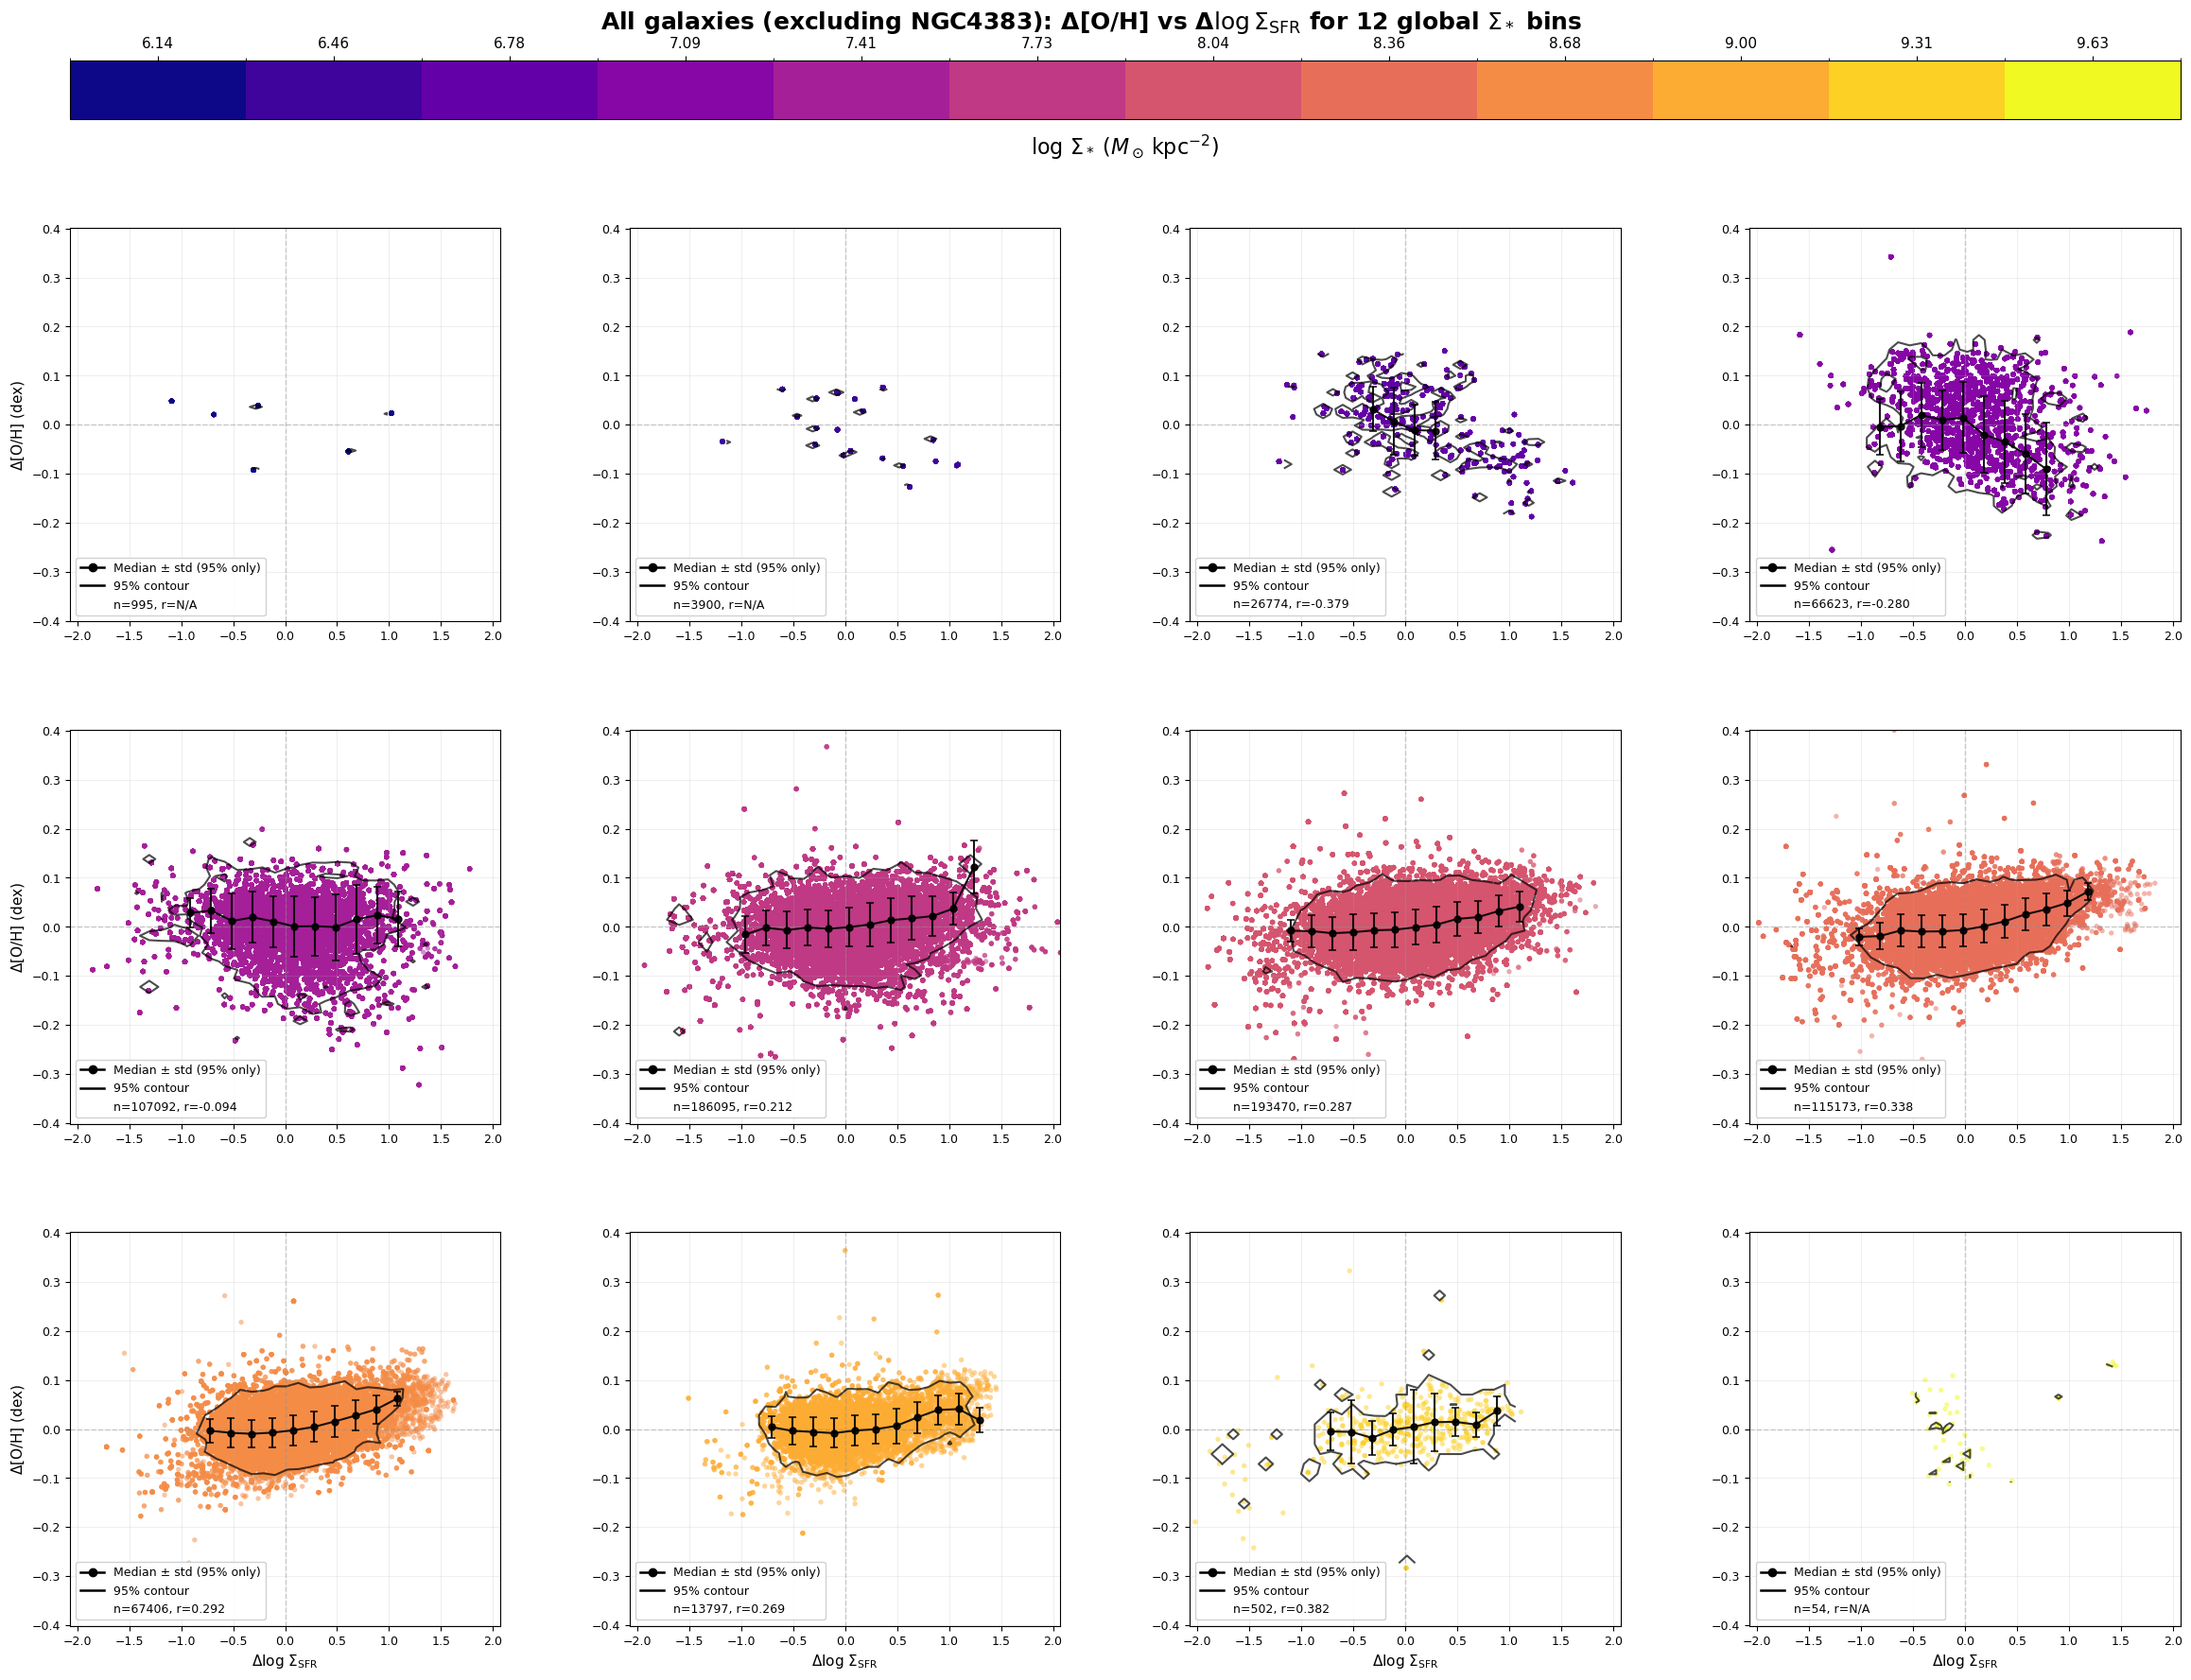

Cell 3: 12-panel offset relation grid complete for all galaxies (excluding NGC4383).


In [3]:
# ------------------------------------------------------------------
# Cell 3: 12-panel offset relations for ALL galaxies (excluding NGC4383)
# Each panel is one Σ_* bin; points from all galaxies in that bin
# Pearson r uses same 95% contour + trend definition as Cell 2
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Helper: read the required maps (O3N2, same as Cell 2)
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Build combined sample of all galaxies and define global Σ_* bins
# ------------------------------------------------------------------
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print("Cell 3: 12-panel offset relations for all galaxies (excluding NGC4383)")
print("All galaxies:", ", ".join(galaxies_all))
print("Used galaxies:", ", ".join(galaxies))
print("=" * 80)

# Load all galaxies, stack valid spaxels
sigM_all = []
sigSFR_all = []
oh_all = []

for gal in galaxies:
    try:
        sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f"Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        continue

    sigM_all.append(sigM[valid_all].ravel())
    sigSFR_all.append(sigSFR[valid_all].ravel())
    oh_all.append(oh_o3n2_map[valid_all].ravel())

if not sigM_all:
    print("No valid data across galaxies; nothing to plot.")
else:
    sigM_all = np.concatenate(sigM_all)
    sigSFR_all = np.concatenate(sigSFR_all)
    oh_all = np.concatenate(oh_all)

    # Define 12 global Σ_* bins over the combined sample
    n_bins = 12
    sigmaM_min = np.nanmin(sigM_all)
    sigmaM_max = np.nanmax(sigM_all)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]

    # Use discrete colormap in Σ_*
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    # Global symmetric axis limits using combined sample
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all <= sigmaM_bin_edges[i+1])
        else:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR_all[bin_mask]
            oh_bin = oh_all[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    # ------------------------------------------------------------------
    # Create 3x4 grid of panels + top colorbar
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(24, 18))
    gs = gridspec.GridSpec(4, 4, figure=fig,
                           height_ratios=[0.15, 1, 1, 1],
                           hspace=0.35, wspace=0.3,
                           top=0.96, bottom=0.04, left=0.05, right=0.98)

    cbar_ax = fig.add_subplot(gs[0, :])
    axes = []
    for row in range(3):
        for col in range(4):
            ax = fig.add_subplot(gs[row + 1, col])
            axes.append(ax)

    # ------------------------------------------------------------------
    # For each global Σ_* bin, plot offsets from ALL galaxies
    # and compute Pearson r with same 95% contour + trend rule
    # ------------------------------------------------------------------
    for i in range(n_bins):
        ax = axes[i]

        if i == 0:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all <= sigmaM_bin_edges[i+1])
        else:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])

        n_pixels = np.sum(bin_mask)

        if n_pixels > 0:
            sfr_bin = sigSFR_all[bin_mask]
            oh_bin = oh_all[bin_mask]

            sfr_bin_mean = np.mean(sfr_bin)
            oh_bin_mean = np.mean(oh_bin)

            sfr_offset = sfr_bin - sfr_bin_mean
            oh_offset = oh_bin - oh_bin_mean

            valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

            bin_color = cmap_discrete(norm_discrete(bin_centers[i]))

            ax.scatter(sfr_offset[valid_corr], oh_offset[valid_corr],
                      c=[bin_color], s=15, alpha=0.5, edgecolors='none', rasterized=True)

            # 95% contour using combined sample for this bin
            contour_mask = np.zeros_like(valid_corr, dtype=bool)
            if np.sum(valid_corr) > 20:
                try:
                    H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                       bins=30, density=True)
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2

                    x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                    y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                    x_idx = np.clip(x_idx, 0, H.shape[0]-1)
                    y_idx = np.clip(y_idx, 0, H.shape[1]-1)

                    inside = H[x_idx, y_idx] >= threshold_95
                    contour_mask[valid_corr] = inside

                    X, Y = np.meshgrid(x_centers, y_centers)
                    ax.contour(X, Y, H.T, levels=[threshold_95], colors='black',
                              linewidths=1.5, linestyles='solid', alpha=0.7)
                except Exception:
                    contour_mask[:] = True
            else:
                contour_mask[:] = True

            # Median trend inside 95% contour (same function/thresholds)
            x_trend = sfr_offset[contour_mask]
            y_trend = oh_offset[contour_mask]

            centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                    bin_width=0.2,
                                                                    min_unique=20)

            has_trend = centers.size >= 2
            if has_trend:
                ax.errorbar(centers, medians, yerr=stds,
                           color='black', linewidth=1.5, marker='o', markersize=5,
                           capsize=3, capthick=1.2, zorder=10, alpha=0.9)

            # Pearson r only if trend exists and >2 valid inside contour
            if has_trend and np.sum(contour_mask & valid_corr) > 2:
                try:
                    pearson_r, pearson_p = pearsonr(sfr_offset[contour_mask & valid_corr],
                                                    oh_offset[contour_mask & valid_corr])
                    r_label = f'r={pearson_r:.3f}'
                except Exception:
                    pearson_r, pearson_p = np.nan, np.nan
                    r_label = 'r=N/A'
            else:
                pearson_r, pearson_p = np.nan, np.nan
                r_label = 'r=N/A'

            ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)

            ax.set_xlim(-global_max_abs_sfr, global_max_abs_sfr)
            ax.set_ylim(-global_max_abs_oh, global_max_abs_oh)
            ax.grid(True, alpha=0.2)

            legend_elements = [
                Line2D([0], [0], color='black', linewidth=1.8, marker='o', markersize=6,
                       label='Median ± std (95% only)'),
                Line2D([0], [0], color='black', linewidth=1.8, linestyle='solid',
                       label='95% contour'),
                Line2D([0], [0], color='none',
                       label=f'n={n_pixels}, {r_label}')
]
            ax.legend(handles=legend_elements, loc='lower left', fontsize=9,
                      framealpha=0.9)

            if i % 4 == 0:
                ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=11)
            if i >= 8:
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=11)

            ax.tick_params(labelsize=9)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])

    # Colorbar along top
    sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm_discrete)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=16, labelpad=10)
    cbar.set_ticks(bin_centers)
    cbar.set_ticklabels([f'{bc:.2f}' for bc in bin_centers], fontsize=11)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('bottom')

    fig.suptitle(r'All galaxies (excluding NGC4383): Δ[O/H] vs Δ$\log\Sigma_{\mathrm{SFR}}$ for 12 global $\Sigma_*$ bins',
                 fontsize=18, y=0.99, fontweight='bold')
    plt.show()
    
    print("Cell 3: 12-panel offset relation grid complete for all galaxies (excluding NGC4383).")

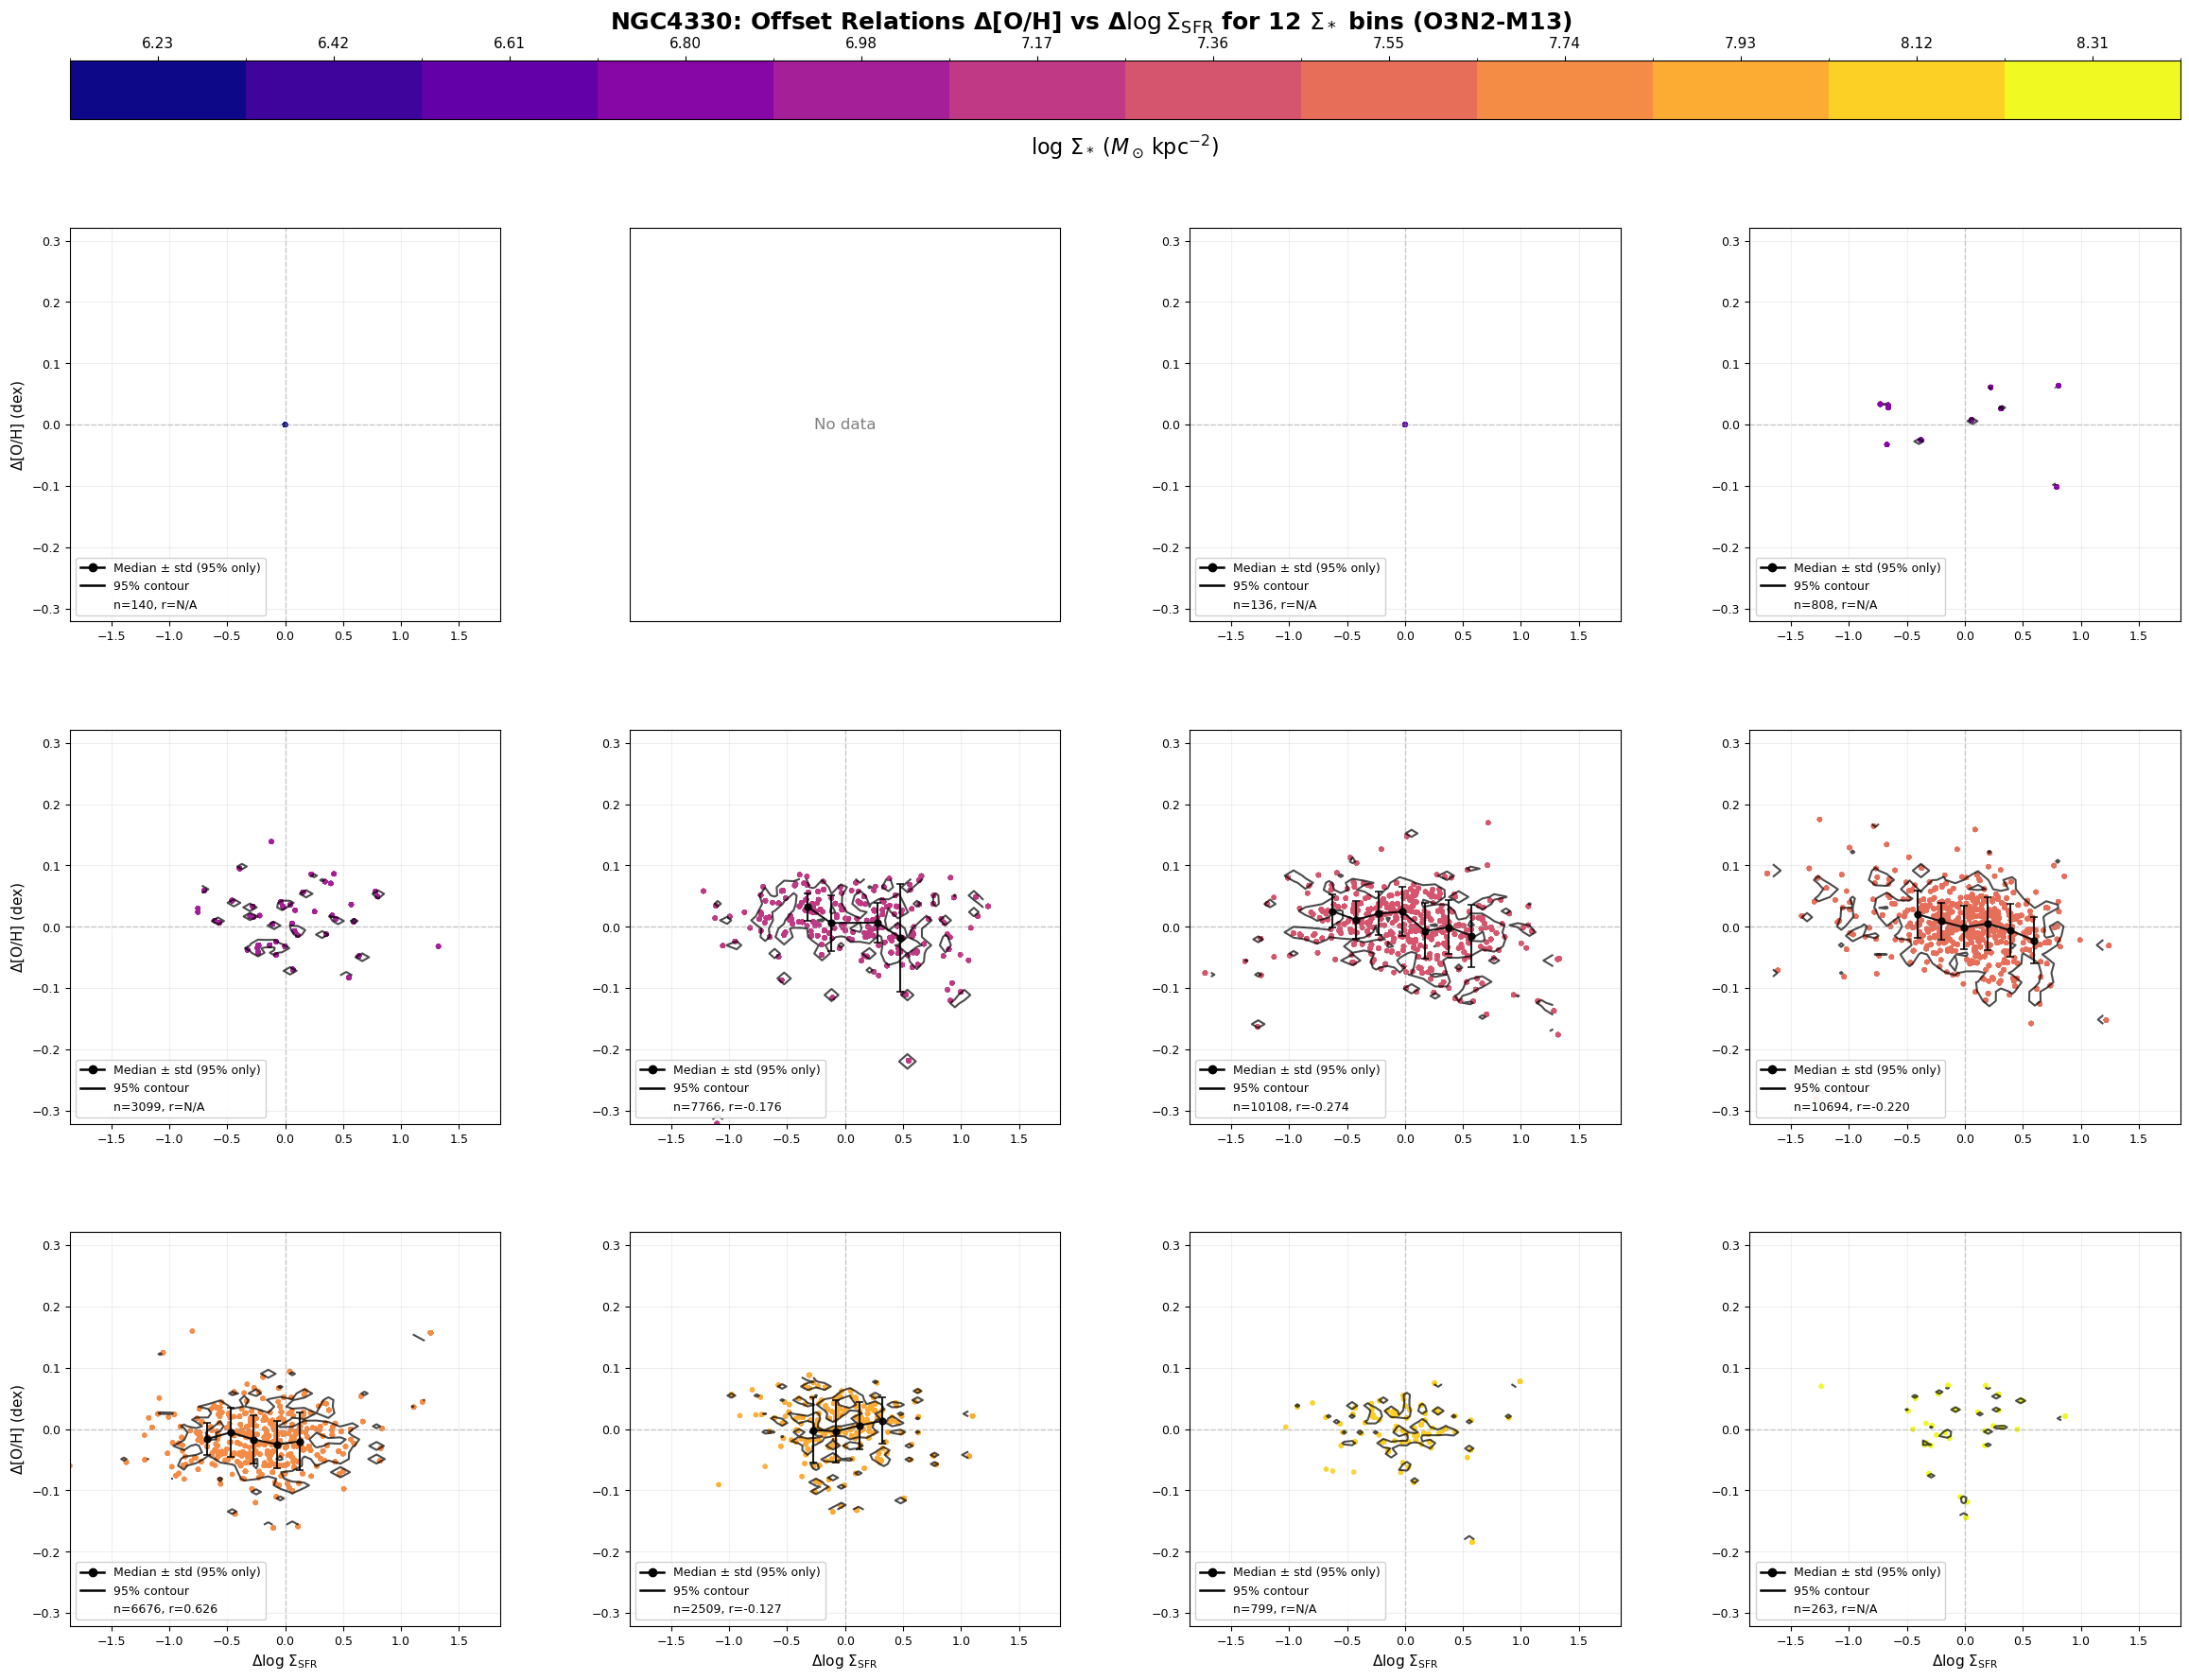


NGC4330: 12-panel offset relation grid complete!
  Number of Σ* bins: 12
  Σ* range: 6.135 to 8.400
  Global Δlog(Σ_SFR) axis limits: ±1.857
  Global Δ[O/H] axis limits: ±0.321


In [4]:
# ------------------------------------------------------------------
# Plot 12 separate offset relations (one per Σ* bin) in 3x4 grid
# With shared colorbar at the top
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins.

    Only keep bins where there are at least `min_unique` unique y-data
    points within the bin. Returns bin centers, medians, stds, and counts.
    """
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        # Require sufficient unique y values in this bin
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 1.  Define 12 Σ* bins
    # ------------------------------------------------------------------
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Calculate bin centers for color mapping
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    
    # Use same discrete colormap as bottom-right panel in cell 8
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    # ------------------------------------------------------------------
    # 2.  Calculate global axis limits (same for all subplots)
    # ------------------------------------------------------------------
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]
            
            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)
            
            global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))
    
    # ------------------------------------------------------------------
    # 3.  Create 3x4 subplot grid with colorbar at top
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(24, 18))
    
    # Create grid: 1 row for colorbar, 3 rows for subplots
    gs = gridspec.GridSpec(4, 4, figure=fig, 
                          height_ratios=[0.15, 1, 1, 1],
                          hspace=0.35, wspace=0.3,
                          top=0.96, bottom=0.04, left=0.05, right=0.98)
    
    # Create colorbar axis at the top (spanning all columns)
    cbar_ax = fig.add_subplot(gs[0, :])
    
    # Create 12 subplots in 3x4 grid
    axes = []
    for row in range(3):
        for col in range(4):
            ax = fig.add_subplot(gs[row + 1, col])
            axes.append(ax)
    
    # ------------------------------------------------------------------
    # 4.  Plot each Σ* bin in its own subplot
    # ------------------------------------------------------------------
    for i in range(n_bins):
        ax = axes[i]
        
        # Define bin mask
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        n_pixels = np.sum(bin_mask)
        
        if n_pixels > 0:
            # Get values in this bin
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]
            
            # Calculate offsets WITHIN this bin
            sfr_bin_mean = np.mean(sfr_bin)
            oh_bin_mean = np.mean(oh_bin)
            
            sfr_offset = sfr_bin - sfr_bin_mean
            oh_offset = oh_bin - oh_bin_mean
            
            # Validity mask in this bin
            valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)
            
            # Get color for this bin
            bin_color = cmap_discrete(norm_discrete(bin_centers[i]))
            
            # Scatter plot (all valid points in bin)
            ax.scatter(sfr_offset[valid_corr], oh_offset[valid_corr], 
                      c=[bin_color], s=15, alpha=0.5, edgecolors='none', rasterized=True)
            
            # ------------------------------------------------------------------
            # Calculate 95% contour and mask
            # ------------------------------------------------------------------
            contour_mask = np.zeros_like(valid_corr, dtype=bool)
            if np.sum(valid_corr) > 20:
                try:
                    H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                       bins=30, density=True)
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2

                    x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                    y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                    x_idx = np.clip(x_idx, 0, H.shape[0]-1)
                    y_idx = np.clip(y_idx, 0, H.shape[1]-1)

                    inside = H[x_idx, y_idx] >= threshold_95
                    contour_mask[valid_corr] = inside

                    X, Y = np.meshgrid(x_centers, y_centers)
                    ax.contour(X, Y, H.T, levels=[threshold_95], colors='black',
                              linewidths=1.5, linestyles='solid', alpha=0.7)
                except Exception:
                    contour_mask[:] = True
            else:
                contour_mask[:] = True
            
            # ------------------------------------------------------------------
            # Calculate median trend using only points inside 95% contour
            # and requiring at least `min_unique` unique y-values per bin
            # ------------------------------------------------------------------
            x_trend = sfr_offset[contour_mask]
            y_trend = oh_offset[contour_mask]

            centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                    bin_width=0.2,
                                                                    min_unique=20)

            has_trend = centers.size > 0
            if has_trend:
                ax.errorbar(centers, medians, yerr=stds,
                           color='black', linewidth=1.5, marker='o', markersize=5,
                           capsize=3, capthick=1.2, zorder=10, alpha=0.9)
            
            # ------------------------------------------------------------------
            # Pearson r: only for points inside 95% contour and only if trend exists
            # ------------------------------------------------------------------
            if has_trend and np.sum(contour_mask & valid_corr) > 2:
                pearson_r, pearson_p = pearsonr(sfr_offset[contour_mask & valid_corr],
                                                oh_offset[contour_mask & valid_corr])
                r_label = f'r={pearson_r:.3f}'
            else:
                pearson_r, pearson_p = np.nan, np.nan
                r_label = 'r=N/A'
            
            # Add zero reference lines
            ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            
            # Set symmetric limits (global)
            ax.set_xlim(-global_max_abs_sfr, global_max_abs_sfr)
            ax.set_ylim(-global_max_abs_oh, global_max_abs_oh)
            
            # Grid
            ax.grid(True, alpha=0.2)
            
            # Legend entries for each subplot: median, contour, n and r
            legend_elements = [
                Line2D([0], [0], color='black', linewidth=1.8, marker='o', markersize=6,
                       label='Median ± std (95% only)'),
                Line2D([0], [0], color='black', linewidth=1.8, linestyle='solid',
                       label='95% contour'),
                Line2D([0], [0], color='none',
                       label=f'n={n_pixels}, {r_label}')
            ]
            ax.legend(handles=legend_elements, loc='lower left', fontsize=9,
                      framealpha=0.9)
            
            # Labels (only on left and bottom edges)
            if i % 4 == 0:  # Left column
                ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=11)
            if i >= 8:  # Bottom row
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=11)
            
            ax.tick_params(labelsize=9)
        else:
            # No data in this bin
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                   transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])
    
    # ------------------------------------------------------------------
    # 5.  Create horizontal colorbar at the top
    # ------------------------------------------------------------------
    sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm_discrete)
    sm.set_array([])
    
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=16, labelpad=10)
    cbar.set_ticks(bin_centers)
    cbar.set_ticklabels([f'{bc:.2f}' for bc in bin_centers], fontsize=11)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('bottom')
    
    fig.suptitle(rf'{gal}: Offset Relations Δ[O/H] vs Δ$\log\Sigma_{{\mathrm{{SFR}}}}$ for 12 $\Sigma_*$ bins ({indicator_name})',
                fontsize=18, y=0.99, fontweight='bold')
    
    plt.show()
    
    print(f"\n{gal}: 12-panel offset relation grid complete!")
    print(f"  Number of Σ* bins: {n_bins}")
    print(f"  Σ* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")


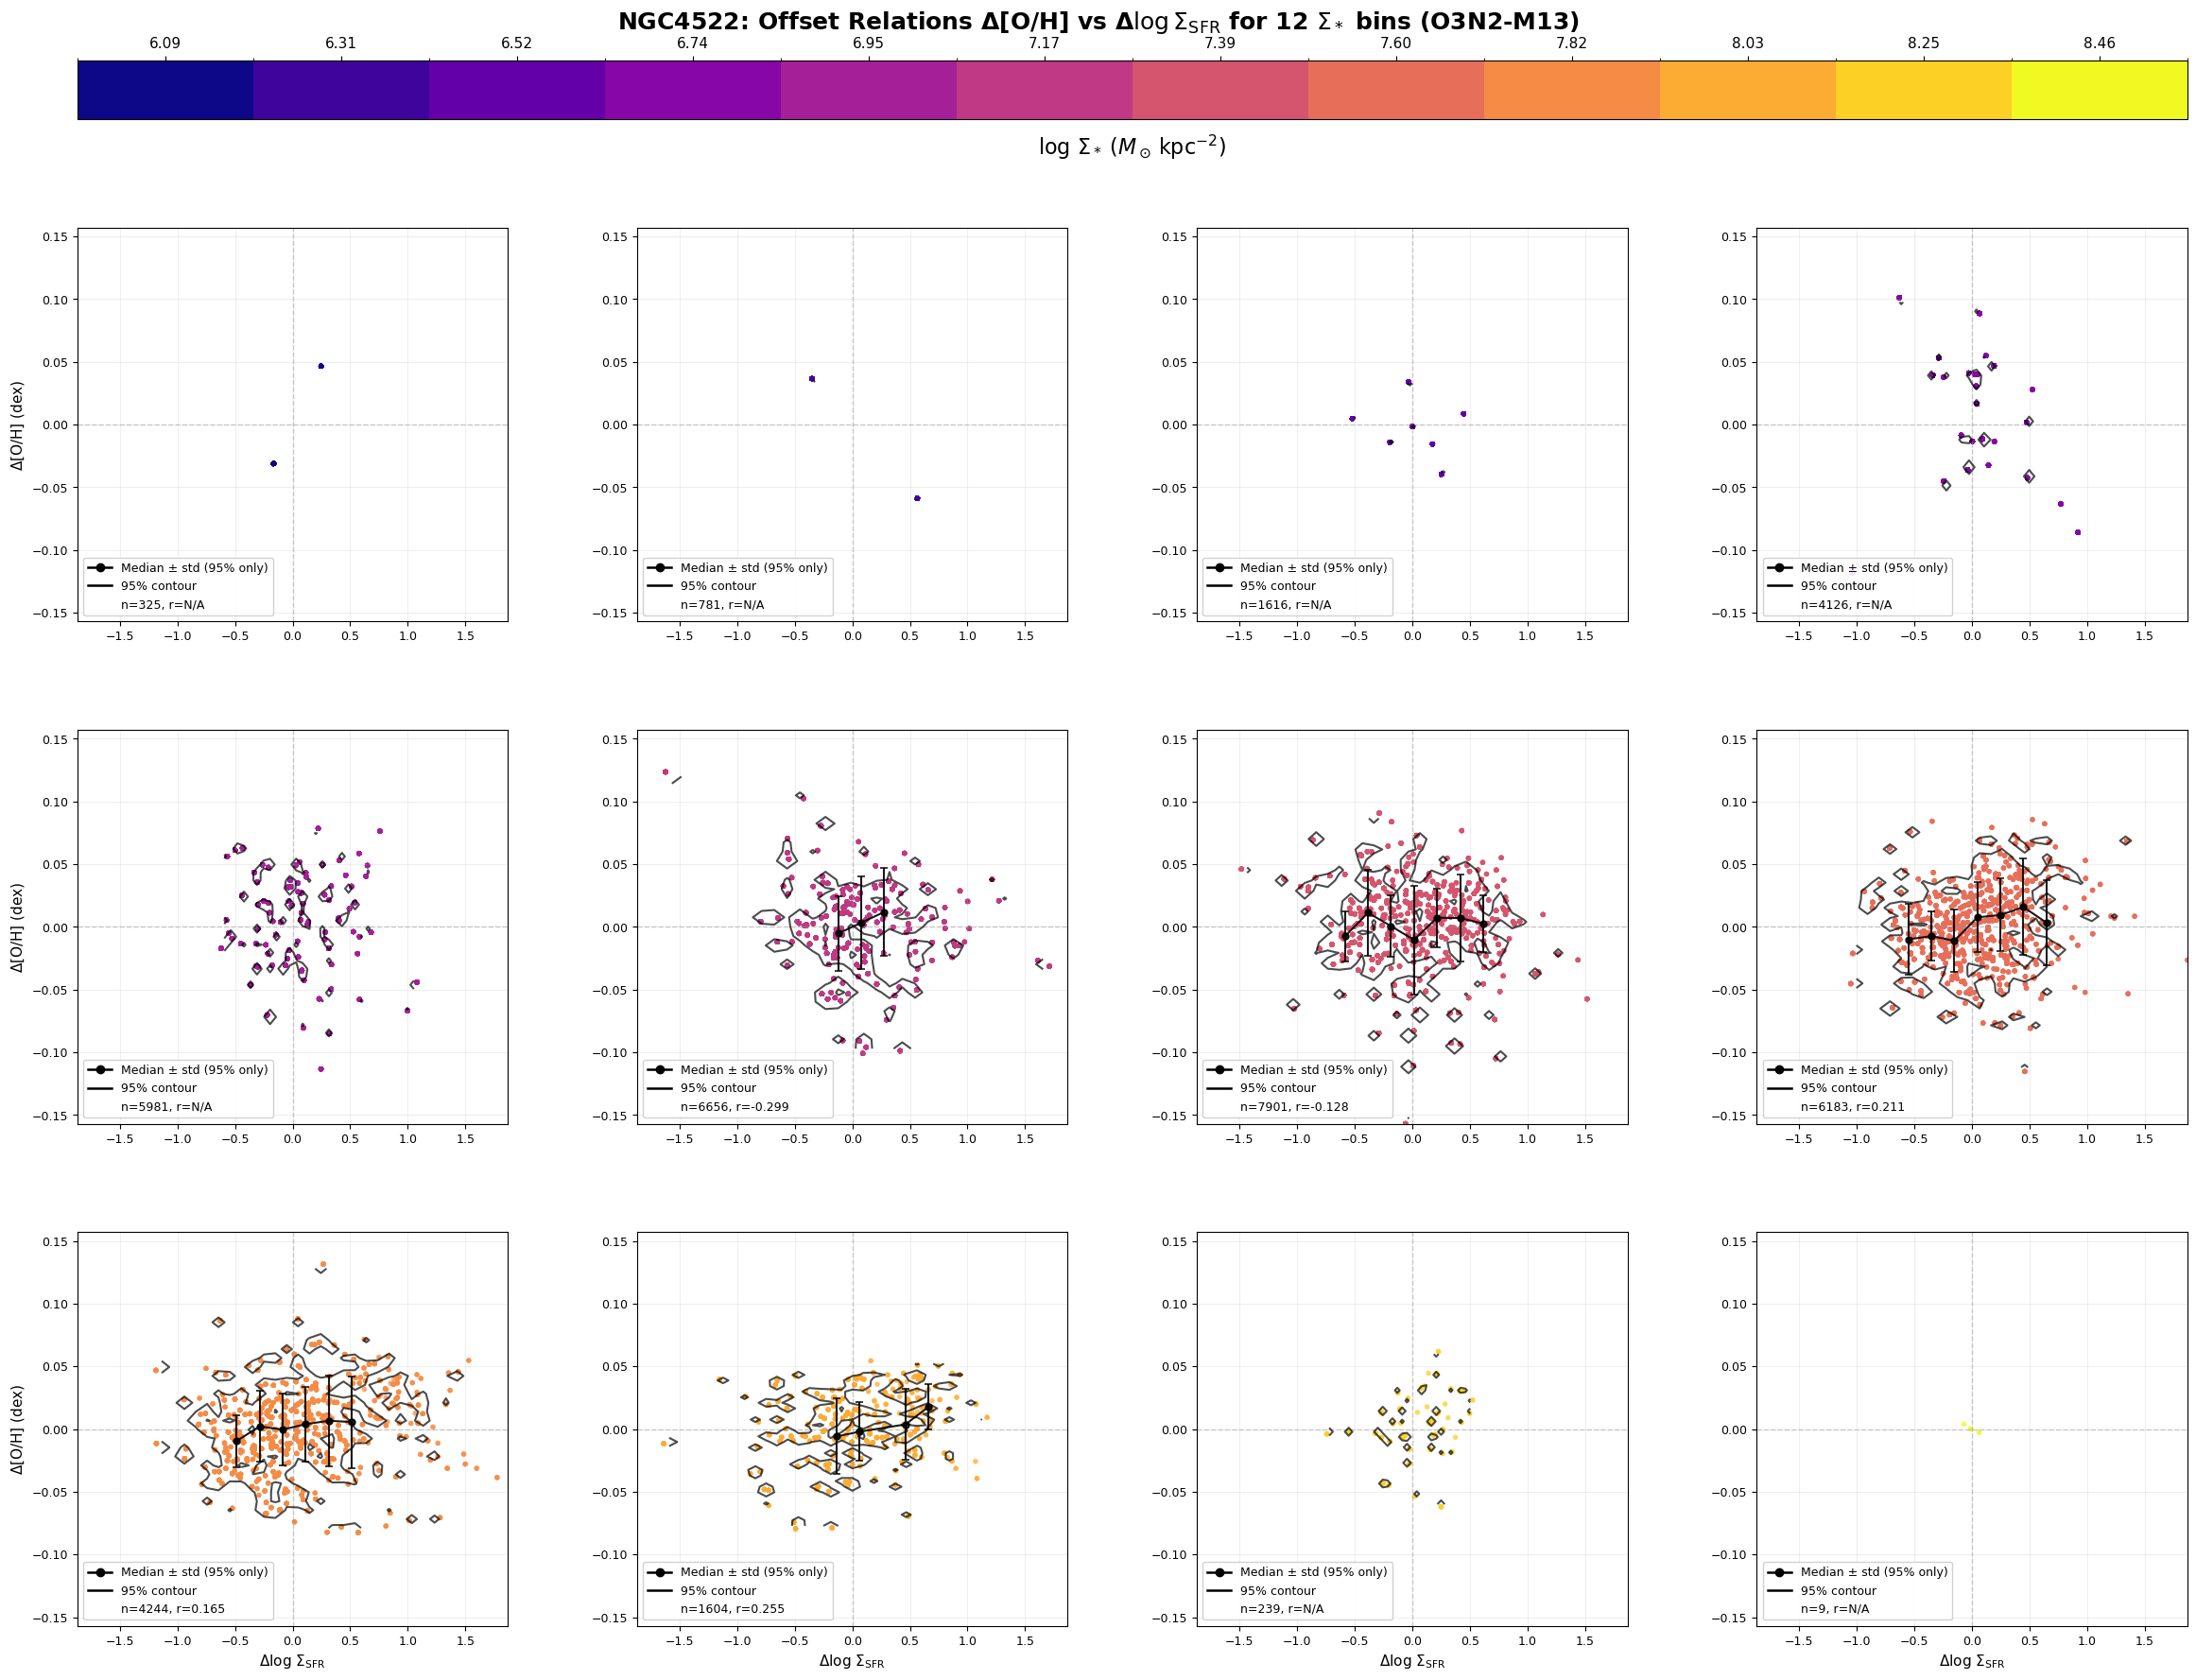


NGC4522: 12-panel offset relation grid complete!
  Number of Σ* bins: 12
  Σ* range: 5.986 to 8.570
  Global Δlog(Σ_SFR) axis limits: ±1.870
  Global Δ[O/H] axis limits: ±0.157


In [5]:
# ------------------------------------------------------------------
# Plot 12 separate offset relations (one per Σ* bin) in 3x4 grid
# With shared colorbar at the top
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins.

    Only keep bins where there are at least `min_unique` unique y-data
    points within the bin. Returns bin centers, medians, stds, and counts.
    """
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        # Require sufficient unique y values in this bin
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# Only focus on NGC4522 for this visualisation
galaxies = ['NGC4522']

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 1.  Define 12 Σ* bins
    # ------------------------------------------------------------------
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Calculate bin centers for color mapping
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    
    # Use same discrete colormap as bottom-right panel in cell 8
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    # ------------------------------------------------------------------
    # 2.  Calculate global axis limits (same for all subplots)
    # ------------------------------------------------------------------
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]
            
            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)
            
            global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))
    
    # ------------------------------------------------------------------
    # 3.  Create 3x4 subplot grid with colorbar at top
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(24, 18))
    
    # Create grid: 1 row for colorbar, 3 rows for subplots
    gs = gridspec.GridSpec(4, 4, figure=fig, 
                          height_ratios=[0.15, 1, 1, 1],
                          hspace=0.35, wspace=0.3,
                          top=0.96, bottom=0.04, left=0.05, right=0.98)
    
    # Create colorbar axis at the top (spanning all columns)
    cbar_ax = fig.add_subplot(gs[0, :])
    
    # Create 12 subplots in 3x4 grid
    axes = []
    for row in range(3):
        for col in range(4):
            ax = fig.add_subplot(gs[row + 1, col])
            axes.append(ax)
    
    # ------------------------------------------------------------------
    # 4.  Plot each Σ* bin in its own subplot
    # ------------------------------------------------------------------
    for i in range(n_bins):
        ax = axes[i]
        
        # Define bin mask
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        n_pixels = np.sum(bin_mask)
        
        if n_pixels > 0:
            # Get values in this bin
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]
            
            # Calculate offsets WITHIN this bin
            sfr_bin_mean = np.mean(sfr_bin)
            oh_bin_mean = np.mean(oh_bin)
            
            sfr_offset = sfr_bin - sfr_bin_mean
            oh_offset = oh_bin - oh_bin_mean
            
            # Validity mask in this bin
            valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)
            
            # Get color for this bin
            bin_color = cmap_discrete(norm_discrete(bin_centers[i]))
            
            # Scatter plot (all valid points in bin)
            ax.scatter(sfr_offset[valid_corr], oh_offset[valid_corr], 
                      c=[bin_color], s=15, alpha=0.5, edgecolors='none', rasterized=True)
            
            # ------------------------------------------------------------------
            # Calculate 95% contour and mask
            # ------------------------------------------------------------------
            contour_mask = np.zeros_like(valid_corr, dtype=bool)
            if np.sum(valid_corr) > 20:
                try:
                    H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                       bins=30, density=True)
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2

                    x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                    y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                    x_idx = np.clip(x_idx, 0, H.shape[0]-1)
                    y_idx = np.clip(y_idx, 0, H.shape[1]-1)

                    inside = H[x_idx, y_idx] >= threshold_95
                    contour_mask[valid_corr] = inside

                    X, Y = np.meshgrid(x_centers, y_centers)
                    ax.contour(X, Y, H.T, levels=[threshold_95], colors='black',
                              linewidths=1.5, linestyles='solid', alpha=0.7)
                except Exception:
                    contour_mask[:] = True
            else:
                contour_mask[:] = True
            
            # ------------------------------------------------------------------
            # Calculate median trend using only points inside 95% contour
            # and requiring at least `min_unique` unique y-values per bin
            # ------------------------------------------------------------------
            x_trend = sfr_offset[contour_mask]
            y_trend = oh_offset[contour_mask]

            centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                    bin_width=0.2,
                                                                    min_unique=20)

            has_trend = centers.size > 0
            if has_trend:
                ax.errorbar(centers, medians, yerr=stds,
                           color='black', linewidth=1.5, marker='o', markersize=5,
                           capsize=3, capthick=1.2, zorder=10, alpha=0.9)
            
            # ------------------------------------------------------------------
            # Pearson r: only for points inside 95% contour and only if trend exists
            # ------------------------------------------------------------------
            if has_trend and np.sum(contour_mask & valid_corr) > 2:
                pearson_r, pearson_p = pearsonr(sfr_offset[contour_mask & valid_corr],
                                                oh_offset[contour_mask & valid_corr])
                r_label = f'r={pearson_r:.3f}'
            else:
                pearson_r, pearson_p = np.nan, np.nan
                r_label = 'r=N/A'
            
            # Add zero reference lines
            ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            
            # Set symmetric limits (global)
            ax.set_xlim(-global_max_abs_sfr, global_max_abs_sfr)
            ax.set_ylim(-global_max_abs_oh, global_max_abs_oh)
            
            # Grid
            ax.grid(True, alpha=0.2)
            
            # Legend entries for each subplot: median, contour, n and r
            legend_elements = [
                Line2D([0], [0], color='black', linewidth=1.8, marker='o', markersize=6,
                       label='Median ± std (95% only)'),
                Line2D([0], [0], color='black', linewidth=1.8, linestyle='solid',
                       label='95% contour'),
                Line2D([0], [0], color='none',
                       label=f'n={n_pixels}, {r_label}')
            ]
            ax.legend(handles=legend_elements, loc='lower left', fontsize=9,
                      framealpha=0.9)
            
            # Labels (only on left and bottom edges)
            if i % 4 == 0:  # Left column
                ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=11)
            if i >= 8:  # Bottom row
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=11)
            
            ax.tick_params(labelsize=9)
        else:
            # No data in this bin
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                   transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])
    
    # ------------------------------------------------------------------
    # 5.  Create horizontal colorbar at the top
    # ------------------------------------------------------------------
    sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm_discrete)
    sm.set_array([])
    
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=16, labelpad=10)
    cbar.set_ticks(bin_centers)
    cbar.set_ticklabels([f'{bc:.2f}' for bc in bin_centers], fontsize=11)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('bottom')
    
    fig.suptitle(rf'{gal}: Offset Relations Δ[O/H] vs Δ$\log\Sigma_{{\mathrm{{SFR}}}}$ for 12 $\Sigma_*$ bins ({indicator_name})',
                fontsize=18, y=0.99, fontweight='bold')
    
    plt.show()
    
    print(f"\n{gal}: 12-panel offset relation grid complete!")
    print(f"  Number of Σ* bins: {n_bins}")
    print(f"  Σ* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")


Offset relations and Pearson r vs Σ_* (D16; excluding: {'NGC4383'})
All galaxies (for color assignment): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Galaxies used in this analysis: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698

Processing IC3392 ...
  Σ* range: 7.310 to 9.297
  Global Δlog(Σ_SFR) axis limits: ±1.953
  Global Δ[O/H] (D16) axis limits: ±0.257
  Pearson r in each Σ_* bin (95% contour + trend, per galaxy):
    Bin 01 (7.39): n=209, r=N/A (no trend or too few in 95%)
    Bin 02 (7.56): n=139, r=N/A (no trend or too few in 95%)
    Bin 03 (7.72): n=244, r=N/A (no trend or too few in 95%)
    Bin 04 (7.89): n=975, r=N/A (no trend or too few in 95%)
    Bin 05 (8.06): n=2954, r=-0.126
    Bin 06 (8.22): n=4888, r=-0.193
    Bin 07 (8.39): n=2989, r=0.104
    Bin 08 (8.55): n=1266, r=-0.035
    Bin 09 (8.72): n=750, r=-0.111
    Bi

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_46534/2753804101.py:443: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


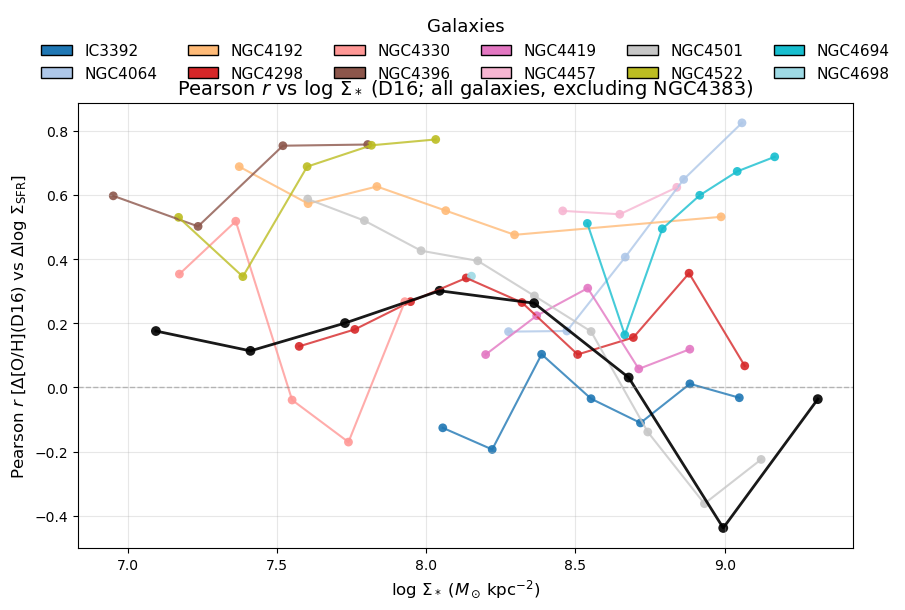

In [6]:
# ------------------------------------------------------------------
# Offset relations: Δ[O/H] (D16) vs Δlog Σ_SFR in Σ_* bins
# For all galaxies (excluding NGC4383) and Pearson r vs Σ_* summary
# Pearson r uses only points inside 95% contour and only if trend exists
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Helper: read the required maps (D16 metallicity)
# ------------------------------------------------------------------
def load_maps_d16(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_D16_HII' in h_gas:
            oh_map = h_gas['O_H_D16_HII'].data
            indicator_name = 'D16'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No D16 metallicity extension found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Galaxy list and color map (reserve color for excluded galaxy)
# ------------------------------------------------------------------
all_bin_centers = []  # Σ_* bin centers for which r is valid (per-galaxy)
all_r_values = []     # Pearson r (per-galaxy)
all_galaxy_indices = []

# Also store all spaxels across galaxies to compute a global trend
global_sigM_list = []
global_sigSFR_list = []
global_oh_list = []
global_gal_index_list = []

# Build full galaxy list from available FITS files (including excluded)
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}

# Build galaxy -> color mapping over ALL galaxies (so excluded keeps its color)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Now define the working sample that EXCLUDES NGC4383 for analysis/plotting
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print(f"Offset relations and Pearson r vs Σ_* (D16; excluding: {excluded_galaxies})")
print("All galaxies (for color assignment):", ", ".join(galaxies_all))
print("Galaxies used in this analysis:", ", ".join(galaxies))
print("=" * 80)

# ------------------------------------------------------------------
# Loop over galaxies and compute Pearson r per Σ_* bin (per-galaxy)
# and collect global spaxels for combined trend
# ------------------------------------------------------------------
for gal_index, gal in enumerate(galaxies):
    print(f"\nProcessing {gal} ...")
    try:
        sigM, sigSFR, oh_d16_map, indicator_name = load_maps_d16(gal)
    except Exception as e:
        print(f"  Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_d16_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        print("  No valid pixels.")
        continue

    # Collect into global arrays for combined analysis
    global_sigM_list.append(sigM[valid_all].ravel())
    global_sigSFR_list.append(sigSFR[valid_all].ravel())
    global_oh_list.append(oh_d16_map[valid_all].ravel())
    global_gal_index_list.append(np.full(np.sum(valid_all), gal_index, dtype=int))

    # 1. Define 12 Σ_* bins for this galaxy
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])

    # 2. Global symmetric limits for this galaxy (for reference / consistency)
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_d16_map[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            if np.any(np.isfinite(sfr_offset)):
                global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            if np.any(np.isfinite(oh_offset)):
                global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    print(f"  Σ* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] (D16) axis limits: ±{global_max_abs_oh:.3f}")

    # 3. Compute Pearson r in each Σ_* bin using 95% contour logic (per galaxy)
    print("  Pearson r in each Σ_* bin (95% contour + trend, per galaxy):")
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        n_pixels = np.sum(bin_mask)

        if n_pixels <= 0:
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, r=N/A")
            continue

        # Values in this Σ_* bin
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_d16_map[bin_mask]

        # Offsets within this bin
        sfr_bin_mean = np.mean(sfr_bin)
        oh_bin_mean = np.mean(oh_bin)

        sfr_offset = sfr_bin - sfr_bin_mean
        oh_offset = oh_bin - oh_bin_mean

        valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

        if np.sum(valid_corr) <= 2:
            pearson_r = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 95% contour and mask, as in the 12-panel code
        # ------------------------------------------------------------------
        contour_mask = np.zeros_like(valid_corr, dtype=bool)
        if np.sum(valid_corr) > 20:
            try:
                H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                   bins=30, density=True)
                H_flat = H.flatten()
                H_sorted = np.sort(H_flat)[::-1]
                H_cumsum = np.cumsum(H_sorted)
                H_cumsum /= H_cumsum[-1]
                threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                x_centers = (xedges[:-1] + xedges[1:]) / 2
                y_centers = (yedges[:-1] + yedges[1:]) / 2

                x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                x_idx = np.clip(x_idx, 0, H.shape[0] - 1)
                y_idx = np.clip(y_idx, 0, H.shape[1] - 1)

                inside = H[x_idx, y_idx] >= threshold_95
                contour_mask[valid_corr] = inside
            except Exception:
                contour_mask[:] = True
        else:
            contour_mask[:] = True

        # ------------------------------------------------------------------
        # Median trend using only points inside 95% contour
        # ------------------------------------------------------------------
        x_trend = sfr_offset[contour_mask]
        y_trend = oh_offset[contour_mask]

        centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                bin_width=0.2,
                                                                min_unique=20)

        # Require at least 2 median-trend points for a valid trend
        has_trend = centers.size >= 2

        # ------------------------------------------------------------------
        # Pearson r: only for points inside 95% contour and only if trend exists
        # ------------------------------------------------------------------
        if has_trend and np.sum(contour_mask & valid_corr) > 2:
            try:
                pearson_r, pearson_p = pearsonr(sfr_offset[contour_mask & valid_corr],
                                                oh_offset[contour_mask & valid_corr])
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r={pearson_r:.3f}")
            except Exception:
                pearson_r = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (error)")
        else:
            pearson_r = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (no trend or too few in 95%)")

        # Store only valid r values
        if np.isfinite(pearson_r):
            all_bin_centers.append(sigmaM_bin_centers[i])
            all_r_values.append(pearson_r)
            all_galaxy_indices.append(gal_index)

# ------------------------------------------------------------------
# Prepare global arrays for combined Pearson vs Σ_* (all galaxies)
# ------------------------------------------------------------------
if global_sigM_list:
    global_sigM = np.concatenate(global_sigM_list)
    global_sigSFR = np.concatenate(global_sigSFR_list)
    global_oh = np.concatenate(global_oh_list)
else:
    global_sigM = np.array([])
    global_sigSFR = np.array([])
    global_oh = np.array([])

# ------------------------------------------------------------------
# Convert collected per-galaxy Pearson r data to arrays
# ------------------------------------------------------------------
all_bin_centers = np.array(all_bin_centers)
all_r_values = np.array(all_r_values)
all_galaxy_indices = np.array(all_galaxy_indices)

print("\n" + "=" * 80)
print("Summary: number of Σ_* bins with valid Pearson r (per galaxy, D16):", len(all_r_values))
print("=" * 80)

# ------------------------------------------------------------------
# Compute combined Pearson r vs Σ_* over all galaxies (same method, D16)
# ------------------------------------------------------------------
global_bin_centers = []
global_r_values = []

if global_sigM.size > 0:
    # Define 12 Σ_* bins for the combined sample
    n_bins_global = 12
    sigmaM_min_g = np.nanmin(global_sigM)
    sigmaM_max_g = np.nanmax(global_sigM)
    sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
    sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

    print("\nComputing combined Pearson r in Σ_* bins (all galaxies together, D16)...")
    for i in range(n_bins_global):
        if i == 0:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])
        elif i == n_bins_global - 1:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i+1])
        else:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])

        n_pix_g = np.sum(bin_mask_g)
        if n_pix_g <= 0:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, r=N/A")
            continue

        sfr_bin_g = global_sigSFR[bin_mask_g]
        oh_bin_g = global_oh[bin_mask_g]

        sfr_mean_g = np.mean(sfr_bin_g)
        oh_mean_g = np.mean(oh_bin_g)

        sfr_off_g = sfr_bin_g - sfr_mean_g
        oh_off_g = oh_bin_g - oh_mean_g

        valid_corr_g = np.isfinite(sfr_off_g) & np.isfinite(oh_off_g)
        if np.sum(valid_corr_g) <= 2:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (insufficient valid points)")
            continue

        contour_mask_g = np.zeros_like(valid_corr_g, dtype=bool)
        if np.sum(valid_corr_g) > 20:
            try:
                Hg, xedges_g, yedges_g = np.histogram2d(sfr_off_g[valid_corr_g], oh_off_g[valid_corr_g],
                                                       bins=30, density=True)
                H_flat_g = Hg.flatten()
                H_sorted_g = np.sort(H_flat_g)[::-1]
                H_cumsum_g = np.cumsum(H_sorted_g)
                H_cumsum_g /= H_cumsum_g[-1]
                thr95_g = H_sorted_g[np.where(H_cumsum_g >= 0.95)[0][0]]

                xcent_g = (xedges_g[:-1] + xedges_g[1:]) / 2
                ycent_g = (yedges_g[:-1] + yedges_g[1:]) / 2

                x_idx_g = np.searchsorted(xedges_g, sfr_off_g[valid_corr_g], side='right') - 1
                y_idx_g = np.searchsorted(yedges_g, oh_off_g[valid_corr_g], side='right') - 1

                x_idx_g = np.clip(x_idx_g, 0, Hg.shape[0] - 1)
                y_idx_g = np.clip(y_idx_g, 0, Hg.shape[1] - 1)

                inside_g = Hg[x_idx_g, y_idx_g] >= thr95_g
                contour_mask_g[valid_corr_g] = inside_g
            except Exception:
                contour_mask_g[:] = True
        else:
            contour_mask_g[:] = True

        x_trend_g = sfr_off_g[contour_mask_g]
        y_trend_g = oh_off_g[contour_mask_g]

        centers_g, medians_g, stds_g, counts_g = calculate_binned_stats(x_trend_g, y_trend_g,
                                                                        bin_width=0.2,
                                                                        min_unique=20)

        has_trend_g = centers_g.size >= 3

        if has_trend_g and np.sum(contour_mask_g & valid_corr_g) > 2:
            try:
                r_g, p_g = pearsonr(sfr_off_g[contour_mask_g & valid_corr_g],
                                     oh_off_g[contour_mask_g & valid_corr_g])
                global_bin_centers.append(sigmaM_centers_g[i])
                global_r_values.append(r_g)
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r={r_g:.3f}")
            except Exception:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r/N/A (error)")
        else:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (no trend or too few in 95%)")

global_bin_centers = np.array(global_bin_centers)
global_r_values = np.array(global_r_values)

# ------------------------------------------------------------------
# Plot Pearson r vs Σ_* for all galaxies, with galaxy color legend
# and an additional combined (all galaxies) trend in black (D16)
# ------------------------------------------------------------------
if len(all_r_values) > 0:
    
    galaxy_indices_unique = np.unique(all_galaxy_indices)
    
    # Create figure with main axis and a thin top axis for legend
    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
    legend_ax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    legend_ax.axis('off')
    
    # Plot Pearson r vs Σ_* for each galaxy
    for idx in galaxy_indices_unique:
        mask = all_galaxy_indices == idx
        gal_name = galaxies[idx]
        color = galaxy_color_dict[gal_name]
        
        # Sort by Σ_* so lines are not scrambled
        x_vals = all_bin_centers[mask]
        y_vals = all_r_values[mask]
        order = np.argsort(x_vals)
        x_sorted = x_vals[order]
        y_sorted = y_vals[order]
        
        ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
        ax.scatter(x_sorted, y_sorted, color=color, s=40, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Add combined trend (all galaxies together) in black (no legend entry)
    if global_r_values.size > 0:
        order_g = np.argsort(global_bin_centers)
        ax.plot(global_bin_centers[order_g], global_r_values[order_g],
                color='black', linewidth=2.0, alpha=0.9, linestyle='-')
        ax.scatter(global_bin_centers[order_g], global_r_values[order_g],
                   color='black', s=50, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Axis formatting
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Pearson $r$ [Δ[O/H](D16) vs Δ$\log\,\Sigma_{\mathrm{SFR}}$]', fontsize=12)
    ax.set_title(r'Pearson $r$ vs $\log\,\Sigma_*$ (D16; all galaxies, excluding NGC4383)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # ------------------------------------------------------------------
    # Galaxy legend at the top using dummy patches (excluding NGC4383)
    # ------------------------------------------------------------------
    galaxy_names = [galaxies[idx] for idx in galaxy_indices_unique]
    legend_elements = [
        Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
        for gal in galaxy_names
]
    legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(galaxy_names), 6),
                      frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)
    
    plt.tight_layout()
    plt.show()
else:
    print("No valid Pearson r values to plot (D16).")

Offset relations and Pearson r vs Σ_* (PG16; excluding: {'NGC4383'})
All galaxies (for color assignment): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Galaxies used in this analysis: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698

Processing IC3392 ...
  Σ* range: 7.310 to 9.297
  Global Δlog(Σ_SFR) axis limits: ±1.953
  Global Δ[O/H] (PG16) axis limits: ±0.115
  Pearson r in each Σ_* bin (95% contour + trend, per galaxy):
    Bin 01 (7.39): n=209, r=N/A (no trend or too few in 95%)
    Bin 02 (7.56): n=139, r=N/A (no trend or too few in 95%)
    Bin 03 (7.72): n=244, r=N/A (no trend or too few in 95%)
    Bin 04 (7.89): n=975, r=N/A (no trend or too few in 95%)
    Bin 05 (8.06): n=2954, r=-0.472
    Bin 06 (8.22): n=4888, r=-0.472
    Bin 07 (8.39): n=2989, r=-0.179
    Bin 08 (8.55): n=1266, r=-0.296
    Bin 09 (8.72): n=750, r=-0.336
   

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_46534/1982390929.py:447: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


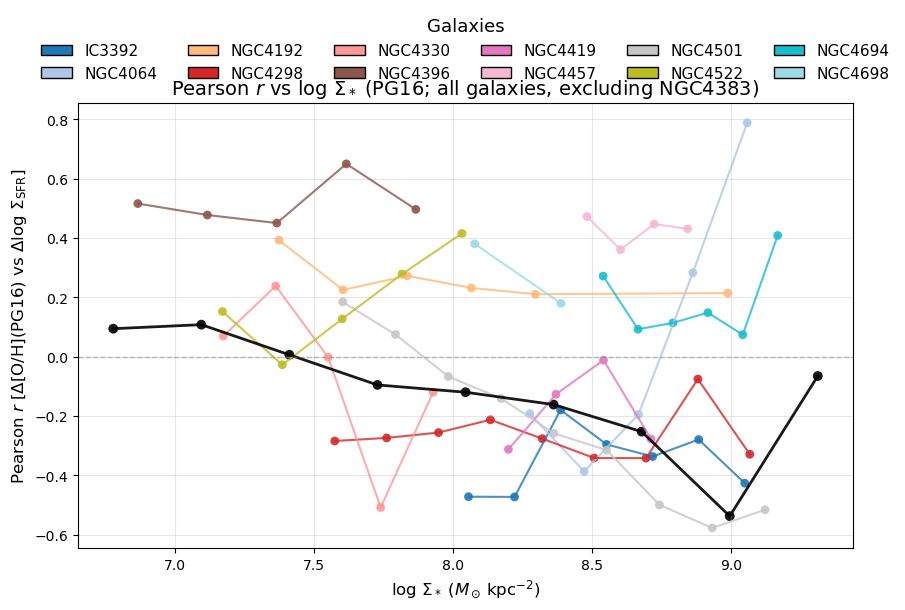

In [7]:
# ------------------------------------------------------------------
# Offset relations: Δ[O/H] (PG16) vs Δlog Σ_SFR in Σ_* bins
# For all galaxies (excluding NGC4383) and Pearson r vs Σ_* summary
# Pearson r uses only points inside 95% contour and only if trend exists
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Helper: read the required maps (PG16 metallicity)
# ------------------------------------------------------------------
def load_maps_pg16(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_PG16scal_HII' in h_gas:
            oh_map = h_gas['O_H_PG16scal_HII'].data
            indicator_name = 'PG16'
        elif 'O_H_PG16_HII' in h_gas:
            # Fallback in case the scale-specific version is not present
            oh_map = h_gas['O_H_PG16_HII'].data
            indicator_name = 'PG16'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No PG16 metallicity extension found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Galaxy list and color map (reserve color for excluded galaxy)
# ------------------------------------------------------------------
all_bin_centers = []  # Σ_* bin centers for which r is valid (per-galaxy)
all_r_values = []     # Pearson r (per-galaxy)
all_galaxy_indices = []

# Also store all spaxels across galaxies to compute a global trend
global_sigM_list = []
global_sigSFR_list = []
global_oh_list = []
global_gal_index_list = []

# Build full galaxy list from available FITS files (including excluded)
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}

# Build galaxy -> color mapping over ALL galaxies (so excluded keeps its color)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Now define the working sample that EXCLUDES NGC4383 for analysis/plotting
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print(f"Offset relations and Pearson r vs Σ_* (PG16; excluding: {excluded_galaxies})")
print("All galaxies (for color assignment):", ", ".join(galaxies_all))
print("Galaxies used in this analysis:", ", ".join(galaxies))
print("=" * 80)

# ------------------------------------------------------------------
# Loop over galaxies and compute Pearson r per Σ_* bin (per-galaxy)
# and collect global spaxels for combined trend
# ------------------------------------------------------------------
for gal_index, gal in enumerate(galaxies):
    print(f"\nProcessing {gal} ...")
    try:
        sigM, sigSFR, oh_pg16_map, indicator_name = load_maps_pg16(gal)
    except Exception as e:
        print(f"  Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_pg16_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        print("  No valid pixels.")
        continue

    # Collect into global arrays for combined analysis
    global_sigM_list.append(sigM[valid_all].ravel())
    global_sigSFR_list.append(sigSFR[valid_all].ravel())
    global_oh_list.append(oh_pg16_map[valid_all].ravel())
    global_gal_index_list.append(np.full(np.sum(valid_all), gal_index, dtype=int))

    # 1. Define 12 Σ_* bins for this galaxy
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])

    # 2. Global symmetric limits for this galaxy (for reference / consistency)
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_pg16_map[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            if np.any(np.isfinite(sfr_offset)):
                global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            if np.any(np.isfinite(oh_offset)):
                global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    print(f"  Σ* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] (PG16) axis limits: ±{global_max_abs_oh:.3f}")

    # 3. Compute Pearson r in each Σ_* bin using 95% contour logic (per galaxy)
    print("  Pearson r in each Σ_* bin (95% contour + trend, per galaxy):")
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        n_pixels = np.sum(bin_mask)

        if n_pixels <= 0:
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, r=N/A")
            continue

        # Values in this Σ_* bin
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_pg16_map[bin_mask]

        # Offsets within this bin
        sfr_bin_mean = np.mean(sfr_bin)
        oh_bin_mean = np.mean(oh_bin)

        sfr_offset = sfr_bin - sfr_bin_mean
        oh_offset = oh_bin - oh_bin_mean

        valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

        if np.sum(valid_corr) <= 2:
            pearson_r = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 95% contour and mask, as in the 12-panel code
        # ------------------------------------------------------------------
        contour_mask = np.zeros_like(valid_corr, dtype=bool)
        if np.sum(valid_corr) > 20:
            try:
                H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                   bins=30, density=True)
                H_flat = H.flatten()
                H_sorted = np.sort(H_flat)[::-1]
                H_cumsum = np.cumsum(H_sorted)
                H_cumsum /= H_cumsum[-1]
                threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                x_centers = (xedges[:-1] + xedges[1:]) / 2
                y_centers = (yedges[:-1] + yedges[1:]) / 2

                x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                x_idx = np.clip(x_idx, 0, H.shape[0] - 1)
                y_idx = np.clip(y_idx, 0, H.shape[1] - 1)

                inside = H[x_idx, y_idx] >= threshold_95
                contour_mask[valid_corr] = inside
            except Exception:
                contour_mask[:] = True
        else:
            contour_mask[:] = True

        # ------------------------------------------------------------------
        # Median trend using only points inside 95% contour
        # ------------------------------------------------------------------
        x_trend = sfr_offset[contour_mask]
        y_trend = oh_offset[contour_mask]

        centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                bin_width=0.2,
                                                                min_unique=20)

        # Require at least 2 median-trend points for a valid trend
        has_trend = centers.size >= 2

        # ------------------------------------------------------------------
        # Pearson r: only for points inside 95% contour and only if trend exists
        # ------------------------------------------------------------------
        if has_trend and np.sum(contour_mask & valid_corr) > 2:
            try:
                pearson_r, pearson_p = pearsonr(sfr_offset[contour_mask & valid_corr],
                                                oh_offset[contour_mask & valid_corr])
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r={pearson_r:.3f}")
            except Exception:
                pearson_r = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (error)")
        else:
            pearson_r = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (no trend or too few in 95%)")

        # Store only valid r values
        if np.isfinite(pearson_r):
            all_bin_centers.append(sigmaM_bin_centers[i])
            all_r_values.append(pearson_r)
            all_galaxy_indices.append(gal_index)

# ------------------------------------------------------------------
# Prepare global arrays for combined Pearson vs Σ_* (all galaxies)
# ------------------------------------------------------------------
if global_sigM_list:
    global_sigM = np.concatenate(global_sigM_list)
    global_sigSFR = np.concatenate(global_sigSFR_list)
    global_oh = np.concatenate(global_oh_list)
else:
    global_sigM = np.array([])
    global_sigSFR = np.array([])
    global_oh = np.array([])

# ------------------------------------------------------------------
# Convert collected per-galaxy Pearson r data to arrays
# ------------------------------------------------------------------
all_bin_centers = np.array(all_bin_centers)
all_r_values = np.array(all_r_values)
all_galaxy_indices = np.array(all_galaxy_indices)

print("\n" + "=" * 80)
print("Summary: number of Σ_* bins with valid Pearson r (per galaxy, PG16):", len(all_r_values))
print("=" * 80)

# ------------------------------------------------------------------
# Compute combined Pearson r vs Σ_* over all galaxies (same method, PG16)
# ------------------------------------------------------------------
global_bin_centers = []
global_r_values = []

if global_sigM.size > 0:
    # Define 12 Σ_* bins for the combined sample
    n_bins_global = 12
    sigmaM_min_g = np.nanmin(global_sigM)
    sigmaM_max_g = np.nanmax(global_sigM)
    sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
    sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

    print("\nComputing combined Pearson r in Σ_* bins (all galaxies together, PG16)...")
    for i in range(n_bins_global):
        if i == 0:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])
        elif i == n_bins_global - 1:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i+1])
        else:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])

        n_pix_g = np.sum(bin_mask_g)
        if n_pix_g <= 0:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, r=N/A")
            continue

        sfr_bin_g = global_sigSFR[bin_mask_g]
        oh_bin_g = global_oh[bin_mask_g]

        sfr_mean_g = np.mean(sfr_bin_g)
        oh_mean_g = np.mean(oh_bin_g)

        sfr_off_g = sfr_bin_g - sfr_mean_g
        oh_off_g = oh_bin_g - oh_mean_g

        valid_corr_g = np.isfinite(sfr_off_g) & np.isfinite(oh_off_g)
        if np.sum(valid_corr_g) <= 2:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (insufficient valid points)")
            continue

        contour_mask_g = np.zeros_like(valid_corr_g, dtype=bool)
        if np.sum(valid_corr_g) > 20:
            try:
                Hg, xedges_g, yedges_g = np.histogram2d(sfr_off_g[valid_corr_g], oh_off_g[valid_corr_g],
                                                       bins=30, density=True)
                H_flat_g = Hg.flatten()
                H_sorted_g = np.sort(H_flat_g)[::-1]
                H_cumsum_g = np.cumsum(H_sorted_g)
                H_cumsum_g /= H_cumsum_g[-1]
                thr95_g = H_sorted_g[np.where(H_cumsum_g >= 0.95)[0][0]]

                xcent_g = (xedges_g[:-1] + xedges_g[1:]) / 2
                ycent_g = (yedges_g[:-1] + yedges_g[1:]) / 2

                x_idx_g = np.searchsorted(xedges_g, sfr_off_g[valid_corr_g], side='right') - 1
                y_idx_g = np.searchsorted(yedges_g, oh_off_g[valid_corr_g], side='right') - 1

                x_idx_g = np.clip(x_idx_g, 0, Hg.shape[0] - 1)
                y_idx_g = np.clip(y_idx_g, 0, Hg.shape[1] - 1)

                inside_g = Hg[x_idx_g, y_idx_g] >= thr95_g
                contour_mask_g[valid_corr_g] = inside_g
            except Exception:
                contour_mask_g[:] = True
        else:
            contour_mask_g[:] = True

        x_trend_g = sfr_off_g[contour_mask_g]
        y_trend_g = oh_off_g[contour_mask_g]

        centers_g, medians_g, stds_g, counts_g = calculate_binned_stats(x_trend_g, y_trend_g,
                                                                        bin_width=0.2,
                                                                        min_unique=20)

        has_trend_g = centers_g.size >= 3

        if has_trend_g and np.sum(contour_mask_g & valid_corr_g) > 2:
            try:
                r_g, p_g = pearsonr(sfr_off_g[contour_mask_g & valid_corr_g],
                                     oh_off_g[contour_mask_g & valid_corr_g])
                global_bin_centers.append(sigmaM_centers_g[i])
                global_r_values.append(r_g)
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r={r_g:.3f}")
            except Exception:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r/N/A (error)")
        else:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (no trend or too few in 95%)")

global_bin_centers = np.array(global_bin_centers)
global_r_values = np.array(global_r_values)

# ------------------------------------------------------------------
# Plot Pearson r vs Σ_* for all galaxies, with galaxy color legend
# and an additional combined (all galaxies) trend in black (PG16)
# ------------------------------------------------------------------
if len(all_r_values) > 0:
    
    galaxy_indices_unique = np.unique(all_galaxy_indices)
    
    # Create figure with main axis and a thin top axis for legend
    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
    legend_ax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    legend_ax.axis('off')
    
    # Plot Pearson r vs Σ_* for each galaxy
    for idx in galaxy_indices_unique:
        mask = all_galaxy_indices == idx
        gal_name = galaxies[idx]
        color = galaxy_color_dict[gal_name]
        
        # Sort by Σ_* so lines are not scrambled
        x_vals = all_bin_centers[mask]
        y_vals = all_r_values[mask]
        order = np.argsort(x_vals)
        x_sorted = x_vals[order]
        y_sorted = y_vals[order]
        
        ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
        ax.scatter(x_sorted, y_sorted, color=color, s=40, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Add combined trend (all galaxies together) in black (no legend entry)
    if global_r_values.size > 0:
        order_g = np.argsort(global_bin_centers)
        ax.plot(global_bin_centers[order_g], global_r_values[order_g],
                color='black', linewidth=2.0, alpha=0.9, linestyle='-')
        ax.scatter(global_bin_centers[order_g], global_r_values[order_g],
                   color='black', s=50, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Axis formatting
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Pearson $r$ [Δ[O/H](PG16) vs Δ$\log\,\Sigma_{\mathrm{SFR}}$]', fontsize=12)
    ax.set_title(r'Pearson $r$ vs $\log\,\Sigma_*$ (PG16; all galaxies, excluding NGC4383)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # ------------------------------------------------------------------
    # Galaxy legend at the top using dummy patches (excluding NGC4383)
    # ------------------------------------------------------------------
    galaxy_names = [galaxies[idx] for idx in galaxy_indices_unique]
    legend_elements = [
        Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
        for gal in galaxy_names
]
    legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(galaxy_names), 6),
                      frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)
    
    plt.tight_layout()
    plt.show()
else:
    print("No valid Pearson r values to plot (PG16).")

Offset relations and Pearson r vs Σ_* (O3N2-C20; excluding: {'NGC4383'})
All galaxies (for color assignment): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Galaxies used in this analysis: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698

Processing IC3392 ...
  Σ* range: 7.310 to 9.297
  Global Δlog(Σ_SFR) axis limits: ±1.953
  Global Δ[O/H] (O3N2-C20) axis limits: ±0.214
  Pearson r in each Σ_* bin (95% contour + trend, per galaxy):
    Bin 01 (7.39): n=209, r=N/A (no trend or too few in 95%)
    Bin 02 (7.56): n=139, r=N/A (no trend or too few in 95%)
    Bin 03 (7.72): n=244, r=N/A (no trend or too few in 95%)
    Bin 04 (7.89): n=975, r=N/A (no trend or too few in 95%)
    Bin 05 (8.06): n=2954, r=0.280
    Bin 06 (8.22): n=4888, r=0.269
    Bin 07 (8.39): n=2989, r=0.169
    Bin 08 (8.55): n=1266, r=0.254
    Bin 09 (8.72): n=750, r=0.138


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_46534/879312930.py:443: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


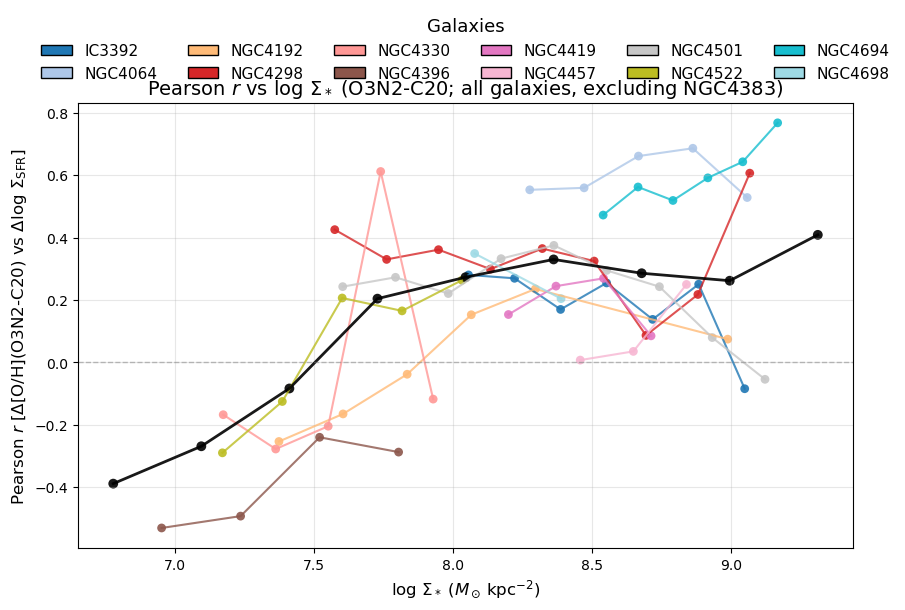

In [8]:
# ------------------------------------------------------------------
# Offset relations: Δ[O/H] (O3N2-C20) vs Δlog Σ_SFR in Σ_* bins
# For all galaxies (excluding NGC4383) and Pearson r vs Σ_* summary
# Pearson r uses only points inside 95% contour and only if trend exists
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Helper: read the required maps (O3N2-C20 metallicity)
# ------------------------------------------------------------------
def load_maps_o3n2_c20(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_C20_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_C20_HII'].data
            indicator_name = 'O3N2-C20'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2-C20 metallicity extension found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Galaxy list and color map (reserve color for excluded galaxy)
# ------------------------------------------------------------------
all_bin_centers = []  # Σ_* bin centers for which r is valid (per-galaxy)
all_r_values = []     # Pearson r (per-galaxy)
all_galaxy_indices = []

# Also store all spaxels across galaxies to compute a global trend
global_sigM_list = []
global_sigSFR_list = []
global_oh_list = []
global_gal_index_list = []

# Build full galaxy list from available FITS files (including excluded)
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}

# Build galaxy -> color mapping over ALL galaxies (so excluded keeps its color)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Now define the working sample that EXCLUDES NGC4383 for analysis/plotting
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print(f"Offset relations and Pearson r vs Σ_* (O3N2-C20; excluding: {excluded_galaxies})")
print("All galaxies (for color assignment):", ", ".join(galaxies_all))
print("Galaxies used in this analysis:", ", ".join(galaxies))
print("=" * 80)

# ------------------------------------------------------------------
# Loop over galaxies and compute Pearson r per Σ_* bin (per-galaxy)
# and collect global spaxels for combined trend
# ------------------------------------------------------------------
for gal_index, gal in enumerate(galaxies):
    print(f"\nProcessing {gal} ...")
    try:
        sigM, sigSFR, oh_o3n2_c20_map, indicator_name = load_maps_o3n2_c20(gal)
    except Exception as e:
        print(f"  Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_c20_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        print("  No valid pixels.")
        continue

    # Collect into global arrays for combined analysis
    global_sigM_list.append(sigM[valid_all].ravel())
    global_sigSFR_list.append(sigSFR[valid_all].ravel())
    global_oh_list.append(oh_o3n2_c20_map[valid_all].ravel())
    global_gal_index_list.append(np.full(np.sum(valid_all), gal_index, dtype=int))

    # 1. Define 12 Σ_* bins for this galaxy
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])

    # 2. Global symmetric limits for this galaxy (for reference / consistency)
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_c20_map[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            if np.any(np.isfinite(sfr_offset)):
                global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            if np.any(np.isfinite(oh_offset)):
                global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    print(f"  Σ* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] (O3N2-C20) axis limits: ±{global_max_abs_oh:.3f}")

    # 3. Compute Pearson r in each Σ_* bin using 95% contour logic (per galaxy)
    print("  Pearson r in each Σ_* bin (95% contour + trend, per galaxy):")
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        n_pixels = np.sum(bin_mask)

        if n_pixels <= 0:
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, r=N/A")
            continue

        # Values in this Σ_* bin
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_o3n2_c20_map[bin_mask]

        # Offsets within this bin
        sfr_bin_mean = np.mean(sfr_bin)
        oh_bin_mean = np.mean(oh_bin)

        sfr_offset = sfr_bin - sfr_bin_mean
        oh_offset = oh_bin - oh_bin_mean

        valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

        if np.sum(valid_corr) <= 2:
            pearson_r = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 95% contour and mask, as in the 12-panel code
        # ------------------------------------------------------------------
        contour_mask = np.zeros_like(valid_corr, dtype=bool)
        if np.sum(valid_corr) > 20:
            try:
                H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                   bins=30, density=True)
                H_flat = H.flatten()
                H_sorted = np.sort(H_flat)[::-1]
                H_cumsum = np.cumsum(H_sorted)
                H_cumsum /= H_cumsum[-1]
                threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                x_centers = (xedges[:-1] + xedges[1:]) / 2
                y_centers = (yedges[:-1] + yedges[1:]) / 2

                x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                x_idx = np.clip(x_idx, 0, H.shape[0] - 1)
                y_idx = np.clip(y_idx, 0, H.shape[1] - 1)

                inside = H[x_idx, y_idx] >= threshold_95
                contour_mask[valid_corr] = inside
            except Exception:
                contour_mask[:] = True
        else:
            contour_mask[:] = True

        # ------------------------------------------------------------------
        # Median trend using only points inside 95% contour
        # ------------------------------------------------------------------
        x_trend = sfr_offset[contour_mask]
        y_trend = oh_offset[contour_mask]

        centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                bin_width=0.2,
                                                                min_unique=20)

        # Require at least 2 median-trend points for a valid trend
        has_trend = centers.size >= 2

        # ------------------------------------------------------------------
        # Pearson r: only for points inside 95% contour and only if trend exists
        # ------------------------------------------------------------------
        if has_trend and np.sum(contour_mask & valid_corr) > 2:
            try:
                pearson_r, pearson_p = pearsonr(sfr_offset[contour_mask & valid_corr],
                                                oh_offset[contour_mask & valid_corr])
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r={pearson_r:.3f}")
            except Exception:
                pearson_r = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (error)")
        else:
            pearson_r = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (no trend or too few in 95%)")

        # Store only valid r values
        if np.isfinite(pearson_r):
            all_bin_centers.append(sigmaM_bin_centers[i])
            all_r_values.append(pearson_r)
            all_galaxy_indices.append(gal_index)

# ------------------------------------------------------------------
# Prepare global arrays for combined Pearson vs Σ_* (all galaxies)
# ------------------------------------------------------------------
if global_sigM_list:
    global_sigM = np.concatenate(global_sigM_list)
    global_sigSFR = np.concatenate(global_sigSFR_list)
    global_oh = np.concatenate(global_oh_list)
else:
    global_sigM = np.array([])
    global_sigSFR = np.array([])
    global_oh = np.array([])

# ------------------------------------------------------------------
# Convert collected per-galaxy Pearson r data to arrays
# ------------------------------------------------------------------
all_bin_centers = np.array(all_bin_centers)
all_r_values = np.array(all_r_values)
all_galaxy_indices = np.array(all_galaxy_indices)

print("\n" + "=" * 80)
print("Summary: number of Σ_* bins with valid Pearson r (per galaxy, O3N2-C20):", len(all_r_values))
print("=" * 80)

# ------------------------------------------------------------------
# Compute combined Pearson r vs Σ_* over all galaxies (same method, O3N2-C20)
# ------------------------------------------------------------------
global_bin_centers = []
global_r_values = []

if global_sigM.size > 0:
    # Define 12 Σ_* bins for the combined sample
    n_bins_global = 12
    sigmaM_min_g = np.nanmin(global_sigM)
    sigmaM_max_g = np.nanmax(global_sigM)
    sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
    sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

    print("\nComputing combined Pearson r in Σ_* bins (all galaxies together, O3N2-C20)...")
    for i in range(n_bins_global):
        if i == 0:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])
        elif i == n_bins_global - 1:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i+1])
        else:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])

        n_pix_g = np.sum(bin_mask_g)
        if n_pix_g <= 0:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, r=N/A")
            continue

        sfr_bin_g = global_sigSFR[bin_mask_g]
        oh_bin_g = global_oh[bin_mask_g]

        sfr_mean_g = np.mean(sfr_bin_g)
        oh_mean_g = np.mean(oh_bin_g)

        sfr_off_g = sfr_bin_g - sfr_mean_g
        oh_off_g = oh_bin_g - oh_mean_g

        valid_corr_g = np.isfinite(sfr_off_g) & np.isfinite(oh_off_g)
        if np.sum(valid_corr_g) <= 2:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (insufficient valid points)")
            continue

        contour_mask_g = np.zeros_like(valid_corr_g, dtype=bool)
        if np.sum(valid_corr_g) > 20:
            try:
                Hg, xedges_g, yedges_g = np.histogram2d(sfr_off_g[valid_corr_g], oh_off_g[valid_corr_g],
                                                       bins=30, density=True)
                H_flat_g = Hg.flatten()
                H_sorted_g = np.sort(H_flat_g)[::-1]
                H_cumsum_g = np.cumsum(H_sorted_g)
                H_cumsum_g /= H_cumsum_g[-1]
                thr95_g = H_sorted_g[np.where(H_cumsum_g >= 0.95)[0][0]]

                xcent_g = (xedges_g[:-1] + xedges_g[1:]) / 2
                ycent_g = (yedges_g[:-1] + yedges_g[1:]) / 2

                x_idx_g = np.searchsorted(xedges_g, sfr_off_g[valid_corr_g], side='right') - 1
                y_idx_g = np.searchsorted(yedges_g, oh_off_g[valid_corr_g], side='right') - 1

                x_idx_g = np.clip(x_idx_g, 0, Hg.shape[0] - 1)
                y_idx_g = np.clip(y_idx_g, 0, Hg.shape[1] - 1)

                inside_g = Hg[x_idx_g, y_idx_g] >= thr95_g
                contour_mask_g[valid_corr_g] = inside_g
            except Exception:
                contour_mask_g[:] = True
        else:
            contour_mask_g[:] = True

        x_trend_g = sfr_off_g[contour_mask_g]
        y_trend_g = oh_off_g[contour_mask_g]

        centers_g, medians_g, stds_g, counts_g = calculate_binned_stats(x_trend_g, y_trend_g,
                                                                        bin_width=0.2,
                                                                        min_unique=20)

        has_trend_g = centers_g.size >= 3

        if has_trend_g and np.sum(contour_mask_g & valid_corr_g) > 2:
            try:
                r_g, p_g = pearsonr(sfr_off_g[contour_mask_g & valid_corr_g],
                                     oh_off_g[contour_mask_g & valid_corr_g])
                global_bin_centers.append(sigmaM_centers_g[i])
                global_r_values.append(r_g)
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r={r_g:.3f}")
            except Exception:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r/N/A (error)")
        else:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (no trend or too few in 95%)")

global_bin_centers = np.array(global_bin_centers)
global_r_values = np.array(global_r_values)

# ------------------------------------------------------------------
# Plot Pearson r vs Σ_* for all galaxies, with galaxy color legend
# and an additional combined (all galaxies) trend in black (O3N2-C20)
# ------------------------------------------------------------------
if len(all_r_values) > 0:
    
    galaxy_indices_unique = np.unique(all_galaxy_indices)
    
    # Create figure with main axis and a thin top axis for legend
    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
    legend_ax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    legend_ax.axis('off')
    
    # Plot Pearson r vs Σ_* for each galaxy
    for idx in galaxy_indices_unique:
        mask = all_galaxy_indices == idx
        gal_name = galaxies[idx]
        color = galaxy_color_dict[gal_name]
        
        # Sort by Σ_* so lines are not scrambled
        x_vals = all_bin_centers[mask]
        y_vals = all_r_values[mask]
        order = np.argsort(x_vals)
        x_sorted = x_vals[order]
        y_sorted = y_vals[order]
        
        ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
        ax.scatter(x_sorted, y_sorted, color=color, s=40, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Add combined trend (all galaxies together) in black (no legend entry)
    if global_r_values.size > 0:
        order_g = np.argsort(global_bin_centers)
        ax.plot(global_bin_centers[order_g], global_r_values[order_g],
                color='black', linewidth=2.0, alpha=0.9, linestyle='-')
        ax.scatter(global_bin_centers[order_g], global_r_values[order_g],
                   color='black', s=50, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Axis formatting
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Pearson $r$ [Δ[O/H](O3N2-C20) vs Δ$\log\,\Sigma_{\mathrm{SFR}}$]', fontsize=12)
    ax.set_title(r'Pearson $r$ vs $\log\,\Sigma_*$ (O3N2-C20; all galaxies, excluding NGC4383)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # ------------------------------------------------------------------
    # Galaxy legend at the top using dummy patches (excluding NGC4383)
    # ------------------------------------------------------------------
    galaxy_names = [galaxies[idx] for idx in galaxy_indices_unique]
    legend_elements = [
        Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
        for gal in galaxy_names
]
    legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(galaxy_names), 6),
                      frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)
    
    plt.tight_layout()
    plt.show()
else:
    print("No valid Pearson r values to plot (O3N2-C20).")
